[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/03-patient_similarity_network_ibs_brain_cognition.ipynb)


Last updated: 2025-12-21, A. Lundervold

Lab 1: use the `bmed365-2026` conda environment

# Patient Similarity Network for Analysis of Brain Morphometry and Cognition in Irritable Bowel Syndrome (IBS)

**A didactic research project based on data from [Lundervold et al. (2025)](https://doi.org/10.3390/diagnostics15040470)**

---

This notebook demonstrates how **patient similarity networks (PSN)** can be used to explore heterogeneity in a clinical population with irritable bowel syndrome (IBS). We combine brain morphometric measures from MRI examinations with cognitive tests to construct networks that reveal patient groups and important clinical features.


---

## Abstract

**Background:** Irritable bowel syndrome (IBS) is a heterogeneous gastrointestinal disorder affecting approximately 10% of the global population. Recent research has uncovered complex gut-brain interactions, including changes in brain morphometry and cognitive function. Patient similarity networks (PSN) represent a promising approach to explore this heterogeneity and identify clinically relevant patient subgroups.

**Methods:** We analyzed data from 78 participants (49 IBS patients and 29 healthy controls) with brain morphometric measures from FreeSurfer and cognitive scores from RBANS. PSN was constructed by calculating similarity between patients based on standardized features. We performed community detection, centrality analyses, compared subnetworks, analyzed feature importance, and examined correlations with symptom severity (IBS-SSS).

**Results:** [Updated after analysis] Network analysis revealed distinct patient clusters with varying composition of IBS patients and controls. Subcortical structures (hippocampus, caudate, putamen) and cognitive domains (memory, verbal skills) were prominent in driving network structure. Centrality measures showed significant correlations with IBS symptom severity.

**Conclusion:** The PSN approach provides valuable insight into heterogeneity in IBS and supports the concept of complex gut-brain interactions. The methodology demonstrates the utility of network-based analyses for understanding clinical complexity in functional gastrointestinal disorders.


---

## 1. Introduction

### 1.1 Motivation and Background

**Irritable bowel syndrome (IBS)** is one of the most prevalent functional gastrointestinal disorders, affecting approximately 10% of the global population [1]. The syndrome is characterized by recurrent abdominal pain associated with defecation, accompanied by changes in bowel habits [2]. The clinical presentation is heterogeneous, with symptoms ranging from mild discomfort to severe complaints that significantly impair quality of life and daily function [3].

IBS is now recognized as a **gut-brain disorder**, where bidirectional interactions between gastrointestinal symptoms and psychological/cognitive function play a central role [4]. While GI symptoms can trigger or amplify psychological stress, anxiety and depression can in turn worsen the frequency and intensity of abdominal pain [5].

Recent research has expanded this psychobiological framework to include **cognitive function**, revealing a more nuanced picture of gut-brain interactions in IBS. Although cognitive impairments have been demonstrated at the group level [6], these appear to characterize specific subgroups rather than being a universal trait of IBS [4].

### 1.2 Patient Similarity Networks (PSN) as an Analytical Approach

**Patient similarity networks** represent a powerful methodology for exploring heterogeneity in clinical populations [7]. In a PSN:

- Each **node** represents a patient
- **Edges** connect patients who resemble each other based on clinical/biological variables  
- **Edge weights** reflect the degree of similarity between patients

This network approach enables:
1. Identifying natural patient groups (communities) without predefined categories
2. Finding "central" patients who are representative of their group
3. Discovering which clinical features drive patient similarity
4. Relating network structure to clinical outcomes

### 1.3 Research Questions

In this study, we apply PSN to data from an IBS cohort to answer the following questions:

1. **Can PSN reveal meaningful subgroups** among IBS patients and healthy controls based on brain morphometry and cognitive measures?

2. **Which brain and cognitive features** drive similarity between patients in the network?

3. **Does network structure differ** between IBS patients and healthy controls?

4. **How do network properties** (e.g., centrality) relate to symptom severity (IBS-SSS)?

### 1.4 Study Objectives

The goal of this notebook is to demonstrate a complete PSN analysis as a didactic research project:

- Construct and visualize PSN from real clinical data
- Perform community detection and evaluate against known groups
- Analyze centrality and identify key patients
- Compare network properties between IBS and controls
- Identify the most important features driving network structure
- Examine clinical correlations with symptom severity


---

## 2. Methods

### 2.1 Study Population and Data

The dataset is from the study by Lundervold et al. (2025) [8] and includes:

- **78 participants**: 49 IBS patients and 29 healthy controls (HC)
- **Brain morphometry**: Volumetric measures from FreeSurfer v7.4.1 processing of structural MR images
- **Cognitive measures**: Index scores from RBANS (Repeatable Battery for the Assessment of Neuropsychological Status)
- **Clinical data**: IBS-SSS (IBS Severity Scoring System), demographic variables

**Variables included:**
- Subcortical volumes (normalized to eTIV): thalamus, caudate, putamen, pallidum, hippocampus, amygdala, nucleus accumbens
- Cerebellum volumes (white and gray matter)
- Corpus callosum segments
- Cerebral white matter and cortex volumes
- RBANS indices: Fullscale, Memory, Visuospatial, Verbal skills, Attention, Recall
- IBS-SSS: Symptom severity score (0-500)

### 2.2 Data Loading and Setup


In [1]:
# ============================================================
# SETUP - Run this cell first!
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Sklearn for preprocessing and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Scipy for distance calculations and statistics
from scipy.spatial.distance import pdist, squareform
from scipy import stats

# Community detection
import community.community_louvain as community_louvain

# Seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ Libraries loaded!")


✓ Libraries loaded!


In [2]:
# ============================================================
# Load data
# ============================================================

def setup_data_path():
    """Set up correct data path for both local execution and Colab"""
    try:
        from google.colab import drive
        # If we are in Colab, download data from GitHub
        !mkdir -p data
        !wget -q -O data/demographics_fs7_rbans_IBS_SSS_imputed_78x48.csv \
            https://raw.githubusercontent.com/arvidl/ibs-brain/main/data/demographics_fs7_rbans_IBS_SSS_imputed_78x48.csv
        return 'data'
    except:
        # Local execution - use relative path
        return os.path.join(os.path.dirname(os.getcwd()), 'data')

# Set up data path and load data
data_path = setup_data_path()
data_file = os.path.join(data_path, 'demographics_fs7_rbans_IBS_SSS_imputed_78x48.csv')

df = pd.read_csv(data_file)

print(f"✓ Data loaded: {df.shape[0]} participants, {df.shape[1]} variables")
print(f"\nGroup distribution:")
print(df['Group'].value_counts())


✓ Data loaded: 78 participants, 48 variables

Group distribution:
Group
IBS    49
HC     29
Name: count, dtype: int64


In [3]:
# Explore the dataset
print("Columns in the dataset:")
print("-" * 50)
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col}")

print(f"\n\nFirst 5 rows:")
df.head()


Columns in the dataset:
--------------------------------------------------
 1. Subject
 2. Group
 3. eTIV
 4. Left-Cerebellum-White-Matter
 5. Left-Cerebellum-Cortex
 6. Left-Thalamus
 7. Left-Caudate
 8. Left-Putamen
 9. Left-Pallidum
10. Left-Hippocampus
11. Left-Amygdala
12. Left-Accumbens-area
13. CSF
14. Right-Cerebellum-White-Matter
15. Right-Cerebellum-Cortex
16. Right-Thalamus
17. Right-Caudate
18. Right-Putamen
19. Right-Pallidum
20. Right-Hippocampus
21. Right-Amygdala
22. Right-Accumbens-area
23. WM-hypointensities
24. CC_Posterior
25. CC_Mid_Posterior
26. CC_Central
27. CC_Mid_Anterior
28. CC_Anterior
29. BrainSegVol
30. BrainSegVolNotVent
31. lhCortexVol
32. rhCortexVol
33. CortexVol
34. lhCerebralWhiteMatterVol
35. rhCerebralWhiteMatterVol
36. CerebralWhiteMatterVol
37. SubCortGrayVol
38. TotalGrayVol
39. Fullscale_RBANS
40. Memory_Index
41. Visuospatial_Index
42. Verbalskills_Index
43. Attention_Index
44. Recall_Index
45. IBS_SSS
46. Age
47. Gender
48. Education


First 

,Subject,Group,eTIV,Left-Cerebellum-White-Matter,Left-Cerebellum-Cortex,Left-Thalamus,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Hippocampus,...,Fullscale_RBANS,Memory_Index,Visuospatial_Index,Verbalskills_Index,Attention_Index,Recall_Index,IBS_SSS,Age,Gender,Education
0,BGA_046,IBS,1.743419e+06,0.009292,0.034808,0.005048,0.002424,0.003358,0.001248,0.003099,...,100,80,102,93,97,86,195.0,38,M,12.0
1,BGA_047,IBS,1.360311e+06,0.009960,0.039399,0.005439,0.002127,0.002992,0.001318,0.002999,...,116,109,107,97,115,126,325.0,19,F,13.0
2,BGA_048,IBS,1.350452e+06,0.011099,0.037770,0.005755,0.002750,0.004094,0.001498,0.003533,...,95,83,84,113,103,100,326.0,34,F,13.0
3,BGA_050,IBS,1.595000e+06,0.010458,0.030902,0.005803,0.002675,0.003622,0.001322,0.002925,...,87,86,97,90,98,86,357.0,44,F,18.0
4,BGA_051,IBS,1.645577e+06,0.010128,0.034373,0.005717,0.002209,0.003332,0.001317,0.002864,...,100,105,90,97,108,100,293.0,38,M,18.0


### 2.3 Data Preprocessing

To construct meaningful patient similarity networks, we must:

1. **Select relevant features**: Numeric variables representing brain morphometry and cognition
2. **Handle missing values**: Imputation with column means
3. **Standardize**: Z-score transformation so that all features contribute equally to the similarity calculation

$$z_i = \frac{x_i - \mu}{\sigma}$$

This ensures that variables with different scales (e.g., brain volumes vs. cognitive scores) are weighted equally.


In [4]:
# ============================================================
# Data Preprocessing
# ============================================================

# Define feature groups for later analysis
morphometry_cols = [col for col in df.columns if col not in 
                   ['Subject', 'Group', 'Age', 'Gender', 'Education', 
                    'Fullscale_RBANS', 'Memory_Index', 'Visuospatial_Index', 
                    'Verbalskills_Index', 'Attention_Index', 'Recall_Index', 'IBS_SSS']]

cognitive_cols = ['Fullscale_RBANS', 'Memory_Index', 'Visuospatial_Index', 
                  'Verbalskills_Index', 'Attention_Index', 'Recall_Index']

# All numeric features for network construction (excluding IBS_SSS for independent analysis)
feature_cols = morphometry_cols + cognitive_cols

print(f"Brain morphometric features: {len(morphometry_cols)}")
print(f"Cognitive features: {len(cognitive_cols)}")
print(f"Total number of features for PSN: {len(feature_cols)}")

# Extract metadata
subjects = df['Subject'].values
groups = df['Group'].values
ibs_sss = df['IBS_SSS'].values

# Extract features
X_raw = df[feature_cols].values

# Handle missing values with mean imputation
X_imputed = pd.DataFrame(X_raw, columns=feature_cols).fillna(
    pd.DataFrame(X_raw, columns=feature_cols).mean()
).values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\n✓ Preprocessing completed!")
print(f"  • Data shape: {X_scaled.shape}")
print(f"  • Missing values handled: {np.isnan(X_raw).sum()}")
print(f"  • Features standardized (mean≈0, std≈1)")


Brain morphometric features: 36
Cognitive features: 6
Total number of features for PSN: 42

✓ Preprocessing completed!
  • Data shape: (78, 42)
  • Missing values handled: 0
  • Features standardized (mean≈0, std≈1)


### 2.4 Network Construction

To construct patient similarity networks, we use the following steps:

**Step 1: Calculate pairwise distances**
We calculate Euclidean distance between all patient pairs in the standardized feature space:

$$d_{ij} = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

**Step 2: Transform to similarity with Gaussian kernel**
Distance is transformed to similarity using a Gaussian (RBF) kernel:

$$s_{ij} = \exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right)$$

where $\sigma$ is set to the mean distance for normalization.

**Step 3: Apply k-nearest-neighbor (k-NN) and threshold**
To avoid overly dense networks, we combine:
- Connect each node to its k nearest neighbors
- Remove edges with similarity below a threshold value

---

## 3. Results

### 3.1 Network Construction and Basic Structure


In [5]:
# ============================================================
# Function for network construction
# ============================================================

def create_psn(X, subjects, groups, threshold=0.3, k_nearest=8):
    """
    Construct a patient similarity network (PSN).
    
    Parameters:
    ----------
    X : ndarray
        Standardized features (n_patients x n_features)
    subjects : array
        Patient IDs
    groups : array
        Group membership (IBS/HC)
    threshold : float
        Minimum similarity for edge (0-1)
    k_nearest : int
        Number of nearest neighbors to connect
        
    Returns:
    -----------
    G : NetworkX Graph
        Patient similarity network
    sim_matrix : ndarray
        Full similarity matrix
    """
    n_patients = len(X)
    
    # Step 1: Calculate pairwise Euclidean distances
    distances = pdist(X, metric='euclidean')
    dist_matrix = squareform(distances)
    
    # Step 2: Transform to similarity with Gaussian kernel
    sigma = np.mean(distances) + 1e-8  # Avoid division by zero
    similarities = np.exp(-distances ** 2 / (2 * sigma ** 2))
    sim_matrix = squareform(similarities)
    
    # Step 3: Build network
    G = nx.Graph()
    
    # Add nodes with attributes
    for i in range(n_patients):
        G.add_node(i, 
                   subject=subjects[i],
                   group=groups[i])
    
    # Add edges based on k-NN and threshold
    for i in range(n_patients):
        # Find k nearest neighbors (exclude self)
        neighbors = np.argsort(sim_matrix[i])[-k_nearest-1:-1]
        for j in neighbors:
            if sim_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=sim_matrix[i, j])
    
    return G, sim_matrix

# Construct network
G, sim_matrix = create_psn(X_scaled, subjects, groups, threshold=0.3, k_nearest=8)

# Calculate layout for visualization
pos = nx.spring_layout(G, k=2, seed=42, iterations=100)

print(f"✓ Network constructed!")
print(f"  • Nodes: {G.number_of_nodes()}")
print(f"  • Edges: {G.number_of_edges()}")
print(f"  • Average degree: {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"  • Network density: {nx.density(G):.4f}")


✓ Network constructed!
  • Nodes: 78
  • Edges: 495
  • Average degree: 12.69
  • Network density: 0.1648


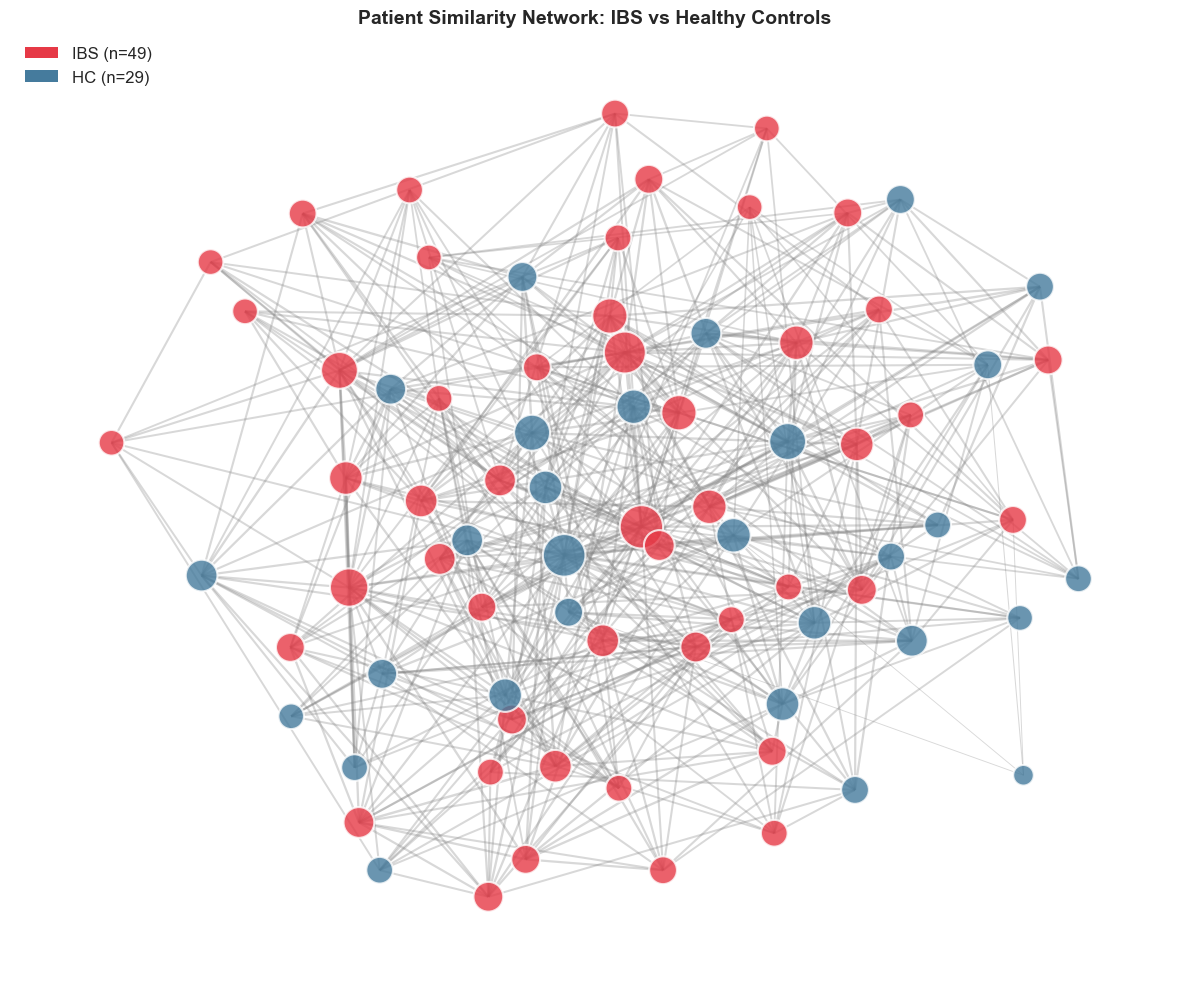


Figure 1: Patient similarity network based on brain morphometry and cognition

Figure caption: Patient similarity network constructed from 78 participants (49 IBS, 
29 HC) based on 41 features (brain morphometry and cognitive measures). Red 
nodes represent IBS patients, blue nodes represent healthy controls. 
Node size reflects degree (number of connections). Edges indicate 
high similarity between patients based on Gaussian kernel-transformed 
Euclidean distances in standardized feature space.



In [6]:
# ============================================================
# Figure 1: Network visualization
# ============================================================

# Define colors for groups
group_colors = {'IBS': '#E63946', 'HC': '#457B9D'}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Get node colors based on group
node_colors = [group_colors[G.nodes[n]['group']] for n in G.nodes()]

# Get edge weights for width/transparency
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths = [w * 2 for w in edge_weights]
edge_alphas = [w * 0.7 for w in edge_weights]

# Calculate node sizes based on degree
degrees = dict(G.degree())
node_sizes = [100 + degrees[n] * 30 for n in G.nodes()]

# Draw edges
nx.draw_networkx_edges(G, pos, ax=ax, 
                       width=edge_widths, 
                       alpha=0.3,
                       edge_color='gray')

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=group_colors['IBS'], label=f'IBS (n={sum(groups=="IBS")})'),
                   Patch(facecolor=group_colors['HC'], label=f'HC (n={sum(groups=="HC")})')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)

ax.set_title('Patient Similarity Network: IBS vs Healthy Controls', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 1: Patient similarity network based on brain morphometry and cognition")
print("="*70)
print("""
Figure caption: Patient similarity network constructed from 78 participants (49 IBS, 
29 HC) based on 41 features (brain morphometry and cognitive measures). Red 
nodes represent IBS patients, blue nodes represent healthy controls. 
Node size reflects degree (number of connections). Edges indicate 
high similarity between patients based on Gaussian kernel-transformed 
Euclidean distances in standardized feature space.
""")


In [7]:
# ============================================================
# Table 1: Basic network metrics
# ============================================================

# Calculate average shortest path first
if nx.is_connected(G):
    avg_path_str = f"{nx.average_shortest_path_length(G):.2f}"
else:
    # Calculate for largest component
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc)
    avg_path_str = f"{nx.average_shortest_path_length(subG):.2f} (largest component)"

# Calculate network metrics
metrics = {
    'Metric': [
        'Number of nodes',
        'Number of edges',
        'Average degree',
        'Network density',
        'Average clustering coefficient',
        'Number of connected components',
        'Average shortest path'
    ],
    'Value': [
        G.number_of_nodes(),
        G.number_of_edges(),
        f"{2*G.number_of_edges()/G.number_of_nodes():.2f}",
        f"{nx.density(G):.4f}",
        f"{nx.average_clustering(G):.3f}",
        nx.number_connected_components(G),
        avg_path_str
    ],
    'Description': [
        'Total number of patients in the network',
        'Number of patient connections',
        'Average number of connections per patient',
        'Proportion of possible connections that exist',
        'Degree of local clustering',
        'Number of separate parts of the network',
        'Average "distance" between patients'
    ]
}

df_metrics = pd.DataFrame(metrics)

print("="*80)
print("Table 1: Basic network metrics")
print("="*80)
print(df_metrics.to_string(index=False))
print("\n" + "="*80)
print("""
Table caption: Summary of basic network properties for the patient 
similarity network. The clustering coefficient indicates to what extent 
neighbors of a node are also connected to each other. Network density 
near 0 indicates a sparse network where only the most similar patients 
are connected.
""")


Table 1: Basic network metrics
                        Metric  Value                                   Description
               Number of nodes     78       Total number of patients in the network
               Number of edges    495                 Number of patient connections
                Average degree  12.69     Average number of connections per patient
               Network density 0.1648 Proportion of possible connections that exist
Average clustering coefficient  0.420                    Degree of local clustering
Number of connected components      1       Number of separate parts of the network
         Average shortest path   2.16           Average "distance" between patients


Table caption: Summary of basic network properties for the patient 
similarity network. The clustering coefficient indicates to what extent 
neighbors of a node are also connected to each other. Network density 
near 0 indicates a sparse network where only the most similar patients 
are connect

### 3.2 Community Detection

**Community detection** identifies groups of nodes that are more densely connected to each other than to the rest of the network. We use the **Louvain algorithm** [9], which optimizes modularity:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $A_{ij}$ is edge weight between node $i$ and $j$
- $k_i$ is degree of node $i$
- $m$ is total edge weight
- $\delta(c_i, c_j) = 1$ if nodes are in the same community

We evaluate how well detected communities match actual groups (IBS/HC) using **Adjusted Rand Index (ARI)**.


In [8]:
# ============================================================
# Community detection with Louvain
# ============================================================

# Run Louvain community detection
communities = community_louvain.best_partition(G, weight='weight', random_state=42)

# Convert to list for easy indexing
community_labels = [communities[i] for i in range(len(communities))]
n_communities = len(set(community_labels))

# Convert actual groups to numeric for ARI calculation
group_numeric = np.array([0 if g == 'IBS' else 1 for g in groups])

# Calculate evaluation metrics
ari = adjusted_rand_score(group_numeric, community_labels)
nmi = normalized_mutual_info_score(group_numeric, community_labels)

print(f"✓ Community detection completed!")
print(f"  • Number of communities detected: {n_communities}")
print(f"  • Adjusted Rand Index (ARI): {ari:.3f}")
print(f"  • Normalized Mutual Information (NMI): {nmi:.3f}")
print(f"\nInterpretation of ARI:")
print(f"  • 1.0 = Perfect match with actual groups")
print(f"  • 0.0 = Random grouping")
print(f"  • < 0 = Worse than random")


✓ Community detection completed!
  • Number of communities detected: 5
  • Adjusted Rand Index (ARI): 0.021
  • Normalized Mutual Information (NMI): 0.065

Interpretation of ARI:
  • 1.0 = Perfect match with actual groups
  • 0.0 = Random grouping
  • < 0 = Worse than random


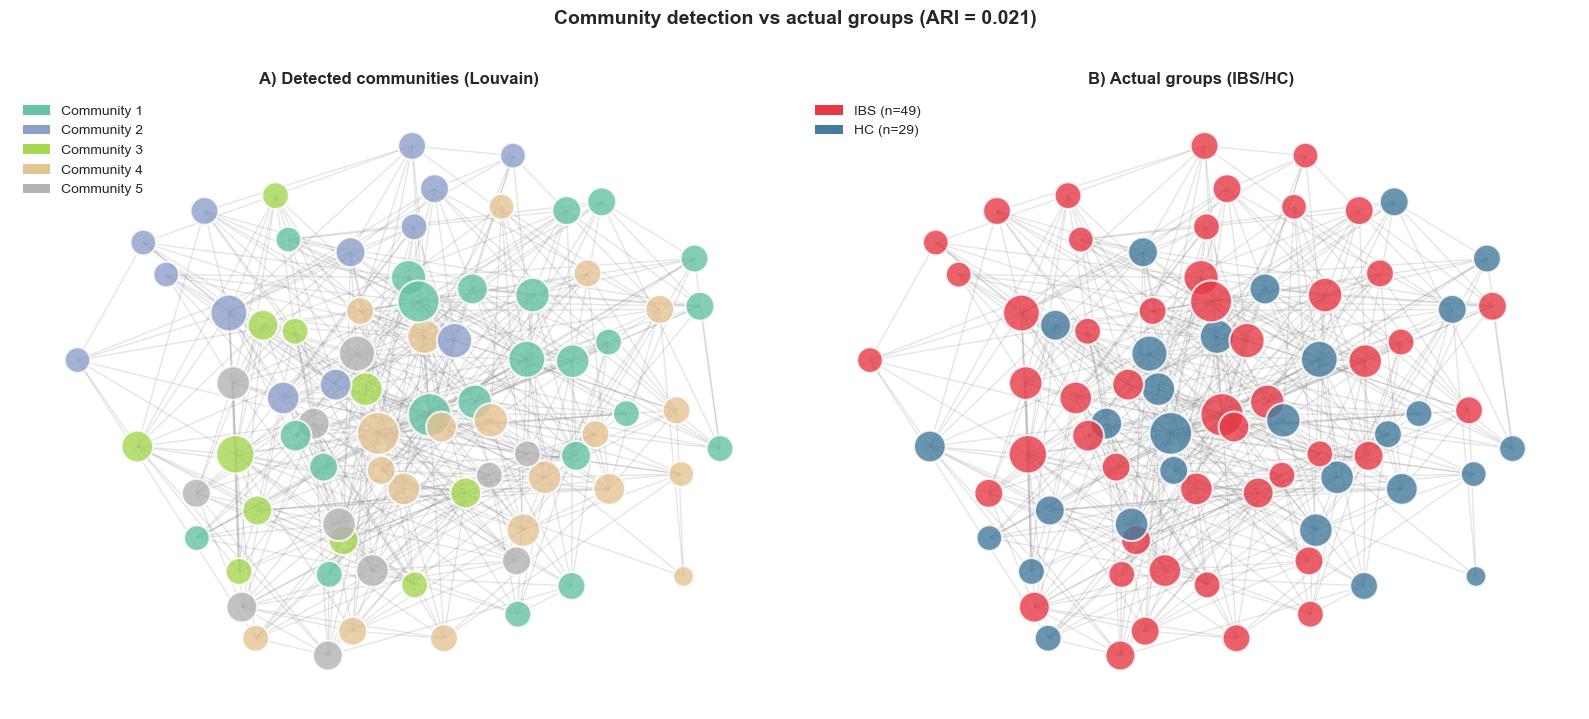


Figure 2: Community detection compared with actual groups

Figure caption: (A) Network visualization with nodes colored by detected 
communities from the Louvain algorithm. (B) Same network with nodes colored 
by actual group membership (IBS=red, HC=blue). ARI = 0.021 indicates 
weak 
agreement between detected communities and actual groups.



In [9]:
# ============================================================
# Figure 2: Network visualization with communities
# ============================================================

# Create a colormap for communities
cmap = plt.cm.get_cmap('Set2', n_communities)
community_colors = [cmap(communities[n]) for n in G.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Colored by community
ax1 = axes[0]
nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1,
                       node_color=community_colors,
                       node_size=node_sizes,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1.5)
ax1.set_title('A) Detected communities (Louvain)', fontsize=12, fontweight='bold')
ax1.axis('off')

# Add community legend
legend_elements_comm = [Patch(facecolor=cmap(i), label=f'Community {i+1}') 
                        for i in range(n_communities)]
ax1.legend(handles=legend_elements_comm, loc='upper left', fontsize=10)

# Right: Colored by actual group
ax2 = axes[1]
nx.draw_networkx_edges(G, pos, ax=ax2, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1.5)
ax2.set_title('B) Actual groups (IBS/HC)', fontsize=12, fontweight='bold')
ax2.axis('off')
ax2.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.suptitle(f'Community detection vs actual groups (ARI = {ari:.3f})', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 2: Community detection compared with actual groups")
print("="*70)
print(f"""
Figure caption: (A) Network visualization with nodes colored by detected 
communities from the Louvain algorithm. (B) Same network with nodes colored 
by actual group membership (IBS=red, HC=blue). ARI = {ari:.3f} indicates 
{'moderate' if 0.3 < ari < 0.7 else 'weak' if ari < 0.3 else 'strong'} 
agreement between detected communities and actual groups.
""")


In [10]:
# ============================================================
# Table 2: Community composition
# ============================================================

# Analyze community composition
community_composition = []
for comm_id in range(n_communities):
    # Find nodes in this community
    nodes_in_comm = [n for n, c in communities.items() if c == comm_id]
    n_total = len(nodes_in_comm)
    n_ibs = sum(1 for n in nodes_in_comm if groups[n] == 'IBS')
    n_hc = sum(1 for n in nodes_in_comm if groups[n] == 'HC')
    pct_ibs = 100 * n_ibs / n_total if n_total > 0 else 0
    
    community_composition.append({
        'Community': comm_id + 1,
        'Total': n_total,
        'IBS': n_ibs,
        'HC': n_hc,
        'IBS %': f"{pct_ibs:.1f}%",
        'Dominant': 'IBS' if pct_ibs > 50 else 'HC' if pct_ibs < 50 else 'Balanced'
    })

df_comm = pd.DataFrame(community_composition)

print("="*70)
print("Table 2: Community composition")
print("="*70)
print(df_comm.to_string(index=False))
print("\n" + "="*70)
print("""
Table caption: Distribution of IBS patients and healthy controls (HC) across 
detected communities. 'Dominant' indicates which group constitutes the 
majority in each community. A heterogeneous distribution indicates that 
the network structure does not perfectly mirror diagnostic groups.
""")


Table 2: Community composition
 Community  Total  IBS  HC IBS % Dominant
         1     23   15   8 65.2%      IBS
         2     13   12   1 92.3%      IBS
         3     11    6   5 54.5%      IBS
         4     20    8  12 40.0%       HC
         5     11    8   3 72.7%      IBS


Table caption: Distribution of IBS patients and healthy controls (HC) across 
detected communities. 'Dominant' indicates which group constitutes the 
majority in each community. A heterogeneous distribution indicates that 
the network structure does not perfectly mirror diagnostic groups.



### 3.3 Centrality Analyses

**Centrality measures** identify the most important nodes in a network. We calculate three complementary measures:

1. **Degree centrality**: How many connections a node has
   $$C_D(v) = \frac{deg(v)}{n-1}$$

2. **Betweenness centrality**: How often a node lies on the shortest path between other nodes
   $$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

3. **Eigenvector centrality**: A node is central if it is connected to other central nodes
   $$C_E(v) = \frac{1}{\lambda} \sum_{u \in N(v)} x_u$$

High centrality can indicate "typical" or "representative" patients for their group.


In [11]:
# ============================================================
# Calculate centrality measures
# ============================================================

# Degree centrality
degree_cent = nx.degree_centrality(G)

# Betweenness centrality
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

# Eigenvector centrality (with convergence handling)
try:
    eigenvector_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except:
    eigenvector_cent = nx.eigenvector_centrality_numpy(G, weight='weight')

# Store centrality values in a DataFrame for further analysis
centrality_df = pd.DataFrame({
    'Node': list(G.nodes()),
    'Subject': [subjects[n] for n in G.nodes()],
    'Group': [groups[n] for n in G.nodes()],
    'Degree': [degree_cent[n] for n in G.nodes()],
    'Betweenness': [betweenness_cent[n] for n in G.nodes()],
    'Eigenvector': [eigenvector_cent[n] for n in G.nodes()]
})

print("✓ Centrality measures calculated!")
print(f"\nSummary per group:")
print("-" * 50)
for group in ['IBS', 'HC']:
    group_data = centrality_df[centrality_df['Group'] == group]
    print(f"\n{group}:")
    print(f"  Degree:      {group_data['Degree'].mean():.4f} ± {group_data['Degree'].std():.4f}")
    print(f"  Betweenness: {group_data['Betweenness'].mean():.4f} ± {group_data['Betweenness'].std():.4f}")
    print(f"  Eigenvector: {group_data['Eigenvector'].mean():.4f} ± {group_data['Eigenvector'].std():.4f}")


✓ Centrality measures calculated!

Summary per group:
--------------------------------------------------

IBS:
  Degree:      0.1627 ± 0.0612
  Betweenness: 0.0138 ± 0.0144
  Eigenvector: 0.1050 ± 0.0516

HC:
  Degree:      0.1684 ± 0.0610
  Betweenness: 0.0185 ± 0.0168
  Eigenvector: 0.0974 ± 0.0451


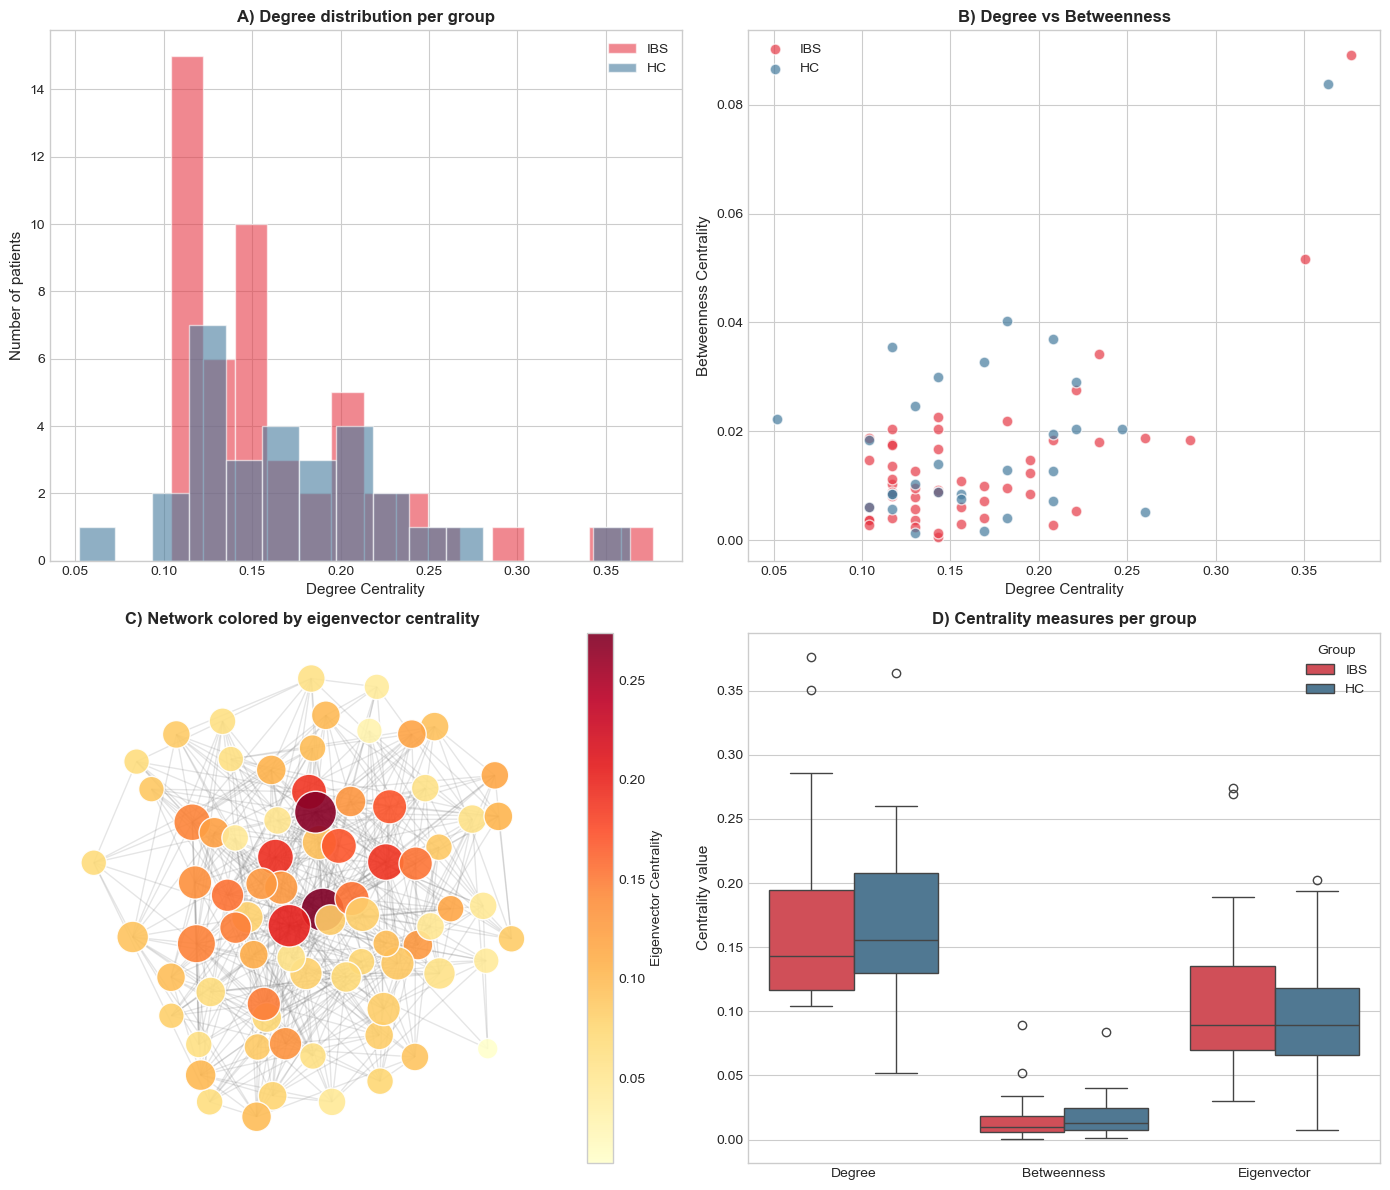


Figure 3: Centrality analysis

Figure caption: Centrality analysis of the patient similarity network. (A) Distribution 
of degree centrality for IBS and HC groups. (B) Scatterplot showing the relationship 
between degree and betweenness centrality. (C) Network visualization where 
node color indicates eigenvector centrality (warmer colors = higher centrality). 
(D) Boxplot comparison of centrality measures between groups.



In [12]:
# ============================================================
# Figure 3: Centrality visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# A) Degree distribution per group
ax1 = axes[0, 0]
for group, color in group_colors.items():
    group_degrees = centrality_df[centrality_df['Group'] == group]['Degree']
    ax1.hist(group_degrees, bins=15, alpha=0.6, label=group, color=color, edgecolor='white')
ax1.set_xlabel('Degree Centrality', fontsize=11)
ax1.set_ylabel('Number of patients', fontsize=11)
ax1.set_title('A) Degree distribution per group', fontsize=12, fontweight='bold')
ax1.legend()

# B) Betweenness vs Degree scatterplot
ax2 = axes[0, 1]
for group, color in group_colors.items():
    group_data = centrality_df[centrality_df['Group'] == group]
    ax2.scatter(group_data['Degree'], group_data['Betweenness'], 
                c=color, label=group, alpha=0.7, s=60, edgecolors='white')
ax2.set_xlabel('Degree Centrality', fontsize=11)
ax2.set_ylabel('Betweenness Centrality', fontsize=11)
ax2.set_title('B) Degree vs Betweenness', fontsize=12, fontweight='bold')
ax2.legend()

# C) Network colored by eigenvector centrality
ax3 = axes[1, 0]
eigenvector_values = [eigenvector_cent[n] for n in G.nodes()]
nx.draw_networkx_edges(G, pos, ax=ax3, alpha=0.2, edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos, ax=ax3,
                               node_color=eigenvector_values,
                               node_size=node_sizes,
                               cmap='YlOrRd',
                               alpha=0.9,
                               edgecolors='white',
                               linewidths=1)
plt.colorbar(nodes, ax=ax3, label='Eigenvector Centrality')
ax3.set_title('C) Network colored by eigenvector centrality', fontsize=12, fontweight='bold')
ax3.axis('off')

# D) Boxplot of centrality measures per group
ax4 = axes[1, 1]
centrality_melted = centrality_df.melt(id_vars=['Group'], 
                                        value_vars=['Degree', 'Betweenness', 'Eigenvector'],
                                        var_name='Centrality measure', value_name='Value')
sns.boxplot(data=centrality_melted, x='Centrality measure', y='Value', hue='Group', 
            palette=group_colors, ax=ax4)
ax4.set_title('D) Centrality measures per group', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Centrality value', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 3: Centrality analysis")
print("="*70)
print("""
Figure caption: Centrality analysis of the patient similarity network. (A) Distribution 
of degree centrality for IBS and HC groups. (B) Scatterplot showing the relationship 
between degree and betweenness centrality. (C) Network visualization where 
node color indicates eigenvector centrality (warmer colors = higher centrality). 
(D) Boxplot comparison of centrality measures between groups.
""")


In [13]:
# ============================================================
# Table 3: Top-10 most central patients
# ============================================================

# Sort by eigenvector centrality (combines degree and network position)
top_10 = centrality_df.nlargest(10, 'Eigenvector')[
    ['Subject', 'Group', 'Degree', 'Betweenness', 'Eigenvector']
].copy()

# Format numbers
top_10['Degree'] = top_10['Degree'].apply(lambda x: f"{x:.4f}")
top_10['Betweenness'] = top_10['Betweenness'].apply(lambda x: f"{x:.4f}")
top_10['Eigenvector'] = top_10['Eigenvector'].apply(lambda x: f"{x:.4f}")

print("="*70)
print("Table 3: Top-10 most central patients (sorted by eigenvector)")
print("="*70)
print(top_10.to_string(index=False))
print("\n" + "="*70)
print("""
Table caption: The 10 patients with highest eigenvector centrality in the network. 
These patients can be considered "typical" or representative of the 
network structure, and are connected to other highly-central patients. 
The distribution between IBS and HC in this list provides insight into network structure.
""")


Table 3: Top-10 most central patients (sorted by eigenvector)
Subject Group Degree Betweenness Eigenvector
BGA_051   IBS 0.3766      0.0892      0.2739
BGA_138   IBS 0.3506      0.0516      0.2694
BGA_091    HC 0.3636      0.0837      0.2023
BGA_092    HC 0.2468      0.0205      0.1941
BGA_130    HC 0.2597      0.0051      0.1904
BGA_060   IBS 0.2338      0.0181      0.1894
BGA_144   IBS 0.2338      0.0342      0.1702
BGA_046   IBS 0.2208      0.0277      0.1699
BGA_056   IBS 0.2208      0.0055      0.1549
BGA_114   IBS 0.1948      0.0123      0.1548


Table caption: The 10 patients with highest eigenvector centrality in the network. 
These patients can be considered "typical" or representative of the 
network structure, and are connected to other highly-central patients. 
The distribution between IBS and HC in this list provides insight into network structure.



### 3.4 Comparison of IBS and HC Subnetworks

To investigate whether IBS patients and healthy controls have different network structure, we construct **separate subnetworks** for each group. We compare:

- Internal connectivity (connections within the group)
- Network density
- Clustering coefficient
- Average shortest path

This reveals whether patients within the same group are more similar to each other than patients across groups.


In [14]:
# ============================================================
# Construct subnetworks for IBS and HC
# ============================================================

# Identify nodes for each group
ibs_nodes = [n for n in G.nodes() if G.nodes[n]['group'] == 'IBS']
hc_nodes = [n for n in G.nodes() if G.nodes[n]['group'] == 'HC']

# Extract subgraphs
G_ibs = G.subgraph(ibs_nodes).copy()
G_hc = G.subgraph(hc_nodes).copy()

def compute_subnetwork_metrics(subG, name):
    """Calculate network metrics for a subnetwork"""
    n_nodes = subG.number_of_nodes()
    n_edges = subG.number_of_edges()
    density = nx.density(subG)
    avg_clustering = nx.average_clustering(subG)
    
    # Average degree
    avg_degree = 2 * n_edges / n_nodes if n_nodes > 0 else 0
    
    # Average shortest path (for largest component)
    if nx.is_connected(subG):
        avg_path = nx.average_shortest_path_length(subG)
    else:
        largest_cc = max(nx.connected_components(subG), key=len) if n_nodes > 0 else set()
        if len(largest_cc) > 1:
            avg_path = nx.average_shortest_path_length(subG.subgraph(largest_cc))
        else:
            avg_path = float('nan')
    
    return {
        'Group': name,
        'Nodes': n_nodes,
        'Edges': n_edges,
        'Density': f"{density:.4f}",
        'Avg degree': f"{avg_degree:.2f}",
        'Clustering': f"{avg_clustering:.3f}",
        'Avg path': f"{avg_path:.2f}" if not np.isnan(avg_path) else "N/A"
    }

# Calculate metrics
ibs_metrics = compute_subnetwork_metrics(G_ibs, 'IBS')
hc_metrics = compute_subnetwork_metrics(G_hc, 'HC')

# Also calculate cross-group edges
cross_edges = [(u, v) for u, v in G.edges() if G.nodes[u]['group'] != G.nodes[v]['group']]
n_cross_edges = len(cross_edges)

print(f"✓ Subnetworks analyzed!")
print(f"  • IBS subnetwork: {G_ibs.number_of_nodes()} nodes, {G_ibs.number_of_edges()} internal edges")
print(f"  • HC subnetwork: {G_hc.number_of_nodes()} nodes, {G_hc.number_of_edges()} internal edges")
print(f"  • Cross-group edges: {n_cross_edges}")


✓ Subnetworks analyzed!
  • IBS subnetwork: 49 nodes, 197 internal edges
  • HC subnetwork: 29 nodes, 78 internal edges
  • Cross-group edges: 220


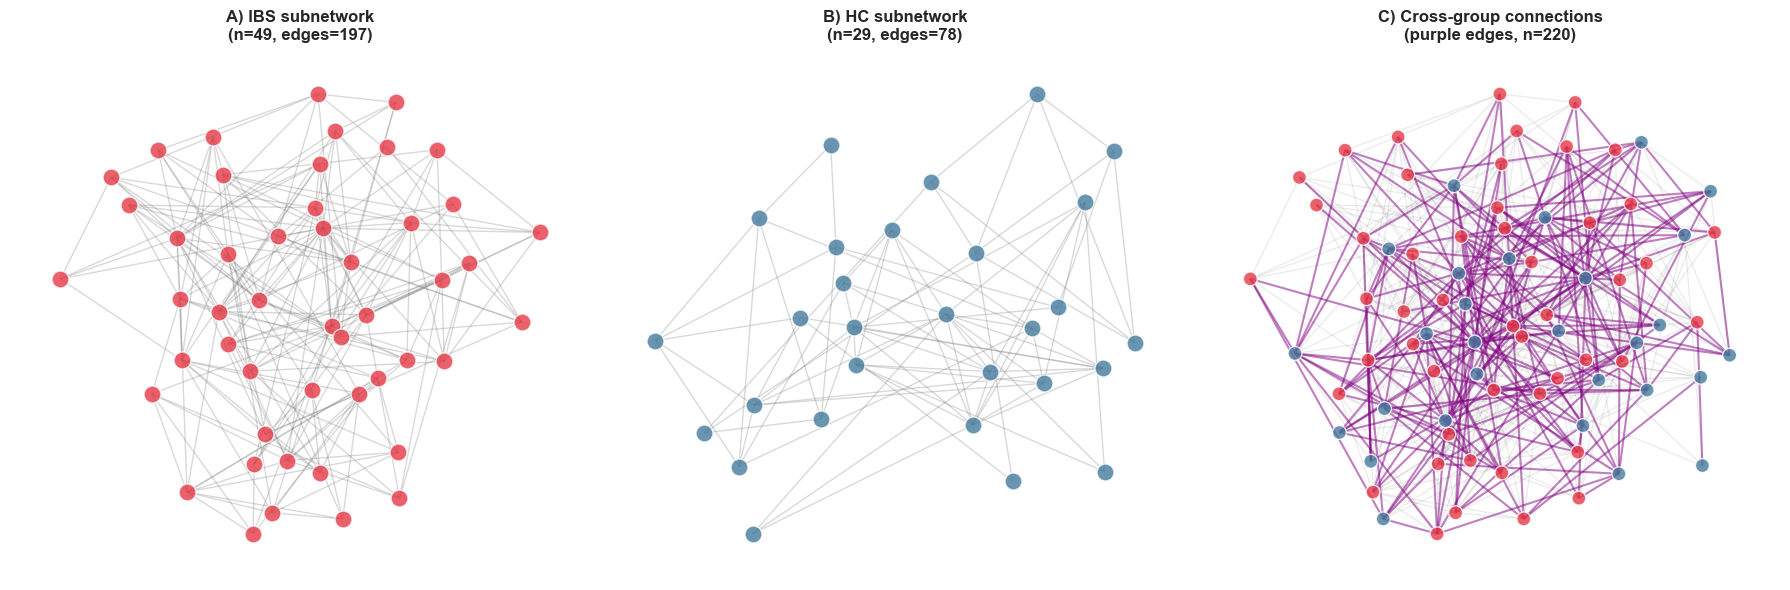


Figure 4: Subnetwork visualization

Figure caption: Comparison of network structure between groups. (A) IBS patients' 
subnetwork with internal connections. (B) HC group's subnetwork. (C) Complete 
network where purple edges mark connections between IBS and HC patients. 
High number of cross-edges indicates overlap in feature profiles between groups.



In [15]:
# ============================================================
# Figure 4: Side-by-side visualization of subnetworks
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A) IBS subnetwork
ax1 = axes[0]
pos_ibs = {n: pos[n] for n in ibs_nodes}
nx.draw_networkx_edges(G_ibs, pos_ibs, ax=ax1, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G_ibs, pos_ibs, ax=ax1,
                       node_color=group_colors['IBS'],
                       node_size=150,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1)
ax1.set_title(f'A) IBS subnetwork\n(n={len(ibs_nodes)}, edges={G_ibs.number_of_edges()})', 
              fontsize=12, fontweight='bold')
ax1.axis('off')

# B) HC subnetwork
ax2 = axes[1]
pos_hc = {n: pos[n] for n in hc_nodes}
nx.draw_networkx_edges(G_hc, pos_hc, ax=ax2, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G_hc, pos_hc, ax=ax2,
                       node_color=group_colors['HC'],
                       node_size=150,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1)
ax2.set_title(f'B) HC subnetwork\n(n={len(hc_nodes)}, edges={G_hc.number_of_edges()})', 
              fontsize=12, fontweight='bold')
ax2.axis('off')

# C) Complete network with cross-edges highlighted
ax3 = axes[2]
# Draw intra-group edges faintly
intra_edges = [(u, v) for u, v in G.edges() if G.nodes[u]['group'] == G.nodes[v]['group']]
nx.draw_networkx_edges(G, pos, edgelist=intra_edges, ax=ax3, alpha=0.15, edge_color='gray')
# Draw cross-group edges more strongly
nx.draw_networkx_edges(G, pos, edgelist=cross_edges, ax=ax3, alpha=0.5, edge_color='purple', width=1.5)
# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax3,
                       node_color=node_colors,
                       node_size=100,
                       alpha=0.8,
                       edgecolors='white',
                       linewidths=1)
ax3.set_title(f'C) Cross-group connections\n(purple edges, n={n_cross_edges})', 
              fontsize=12, fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 4: Subnetwork visualization")
print("="*70)
print("""
Figure caption: Comparison of network structure between groups. (A) IBS patients' 
subnetwork with internal connections. (B) HC group's subnetwork. (C) Complete 
network where purple edges mark connections between IBS and HC patients. 
High number of cross-edges indicates overlap in feature profiles between groups.
""")


In [16]:
# ============================================================
# Table 4: Comparison of subnetworks
# ============================================================

df_subnet = pd.DataFrame([ibs_metrics, hc_metrics])

# Calculate proportion of cross-edges
total_edges = G.number_of_edges()
cross_pct = 100 * n_cross_edges / total_edges

print("="*70)
print("Table 4: Comparison of network properties between groups")
print("="*70)
print(df_subnet.to_string(index=False))
print(f"\nCross-group connections: {n_cross_edges} ({cross_pct:.1f}% of total)")
print("\n" + "="*70)
print("""
Table caption: Comparison of network properties between IBS and HC subnetworks. 
'Density' indicates the proportion of possible connections that exist. 'Clustering' 
measures the degree of cluster formation. Higher density in a subnetwork indicates 
greater internal homogeneity in that group. Cross-group connections show the degree 
of overlap between groups in feature space.
""")


Table 4: Comparison of network properties between groups
Group  Nodes  Edges Density Avg degree Clustering Avg path
  IBS     49    197  0.1675       8.04      0.428     2.31
   HC     29     78  0.1921       5.38      0.406     2.56

Cross-group connections: 220 (44.4% of total)


Table caption: Comparison of network properties between IBS and HC subnetworks. 
'Density' indicates the proportion of possible connections that exist. 'Clustering' 
measures the degree of cluster formation. Higher density in a subnetwork indicates 
greater internal homogeneity in that group. Cross-group connections show the degree 
of overlap between groups in feature space.



### 3.5 Feature Importance Analysis

To understand **which variables** drive network structure, we examine feature importance. We use two complementary approaches:

1. **Correlation with centrality**: Which features correlate with how central a patient is in the network?

2. **Group discrimination**: Which features have the greatest difference between high- and low-centrality patients?

This provides insight into the biological and cognitive factors that define "typical" patients.


In [17]:
# ============================================================
# Feature importance analysis
# ============================================================

# Calculate correlation between each feature and eigenvector centrality
feature_correlations = []
eigenvector_values_array = np.array([eigenvector_cent[i] for i in range(len(X_scaled))])

for i, feature_name in enumerate(feature_cols):
    # Spearman correlation (robust to non-linearity)
    corr, p_value = stats.spearmanr(X_scaled[:, i], eigenvector_values_array)
    
    # Categorize feature
    if feature_name in cognitive_cols:
        category = 'Cognitive'
    else:
        category = 'Brain morphometry'
    
    feature_correlations.append({
        'Feature': feature_name,
        'Category': category,
        'Correlation': corr,
        'P-value': p_value,
        'Abs_corr': abs(corr)
    })

df_feat_imp = pd.DataFrame(feature_correlations)

# Sort by absolute correlation
df_feat_imp_sorted = df_feat_imp.sort_values('Abs_corr', ascending=False)

print("✓ Feature importance calculated!")
print(f"\nTop-10 features correlated with centrality:")
print("-" * 60)
for i, row in df_feat_imp_sorted.head(10).iterrows():
    sig = "**" if row['P-value'] < 0.01 else "*" if row['P-value'] < 0.05 else ""
    print(f"  {row['Feature'][:35]:<35} r={row['Correlation']:+.3f} (p={row['P-value']:.3f}) {sig}")


✓ Feature importance calculated!

Top-10 features correlated with centrality:
------------------------------------------------------------
  SubCortGrayVol                      r=-0.596 (p=0.000) **
  Right-Pallidum                      r=-0.536 (p=0.000) **
  Left-Pallidum                       r=-0.510 (p=0.000) **
  Right-Amygdala                      r=-0.455 (p=0.000) **
  TotalGrayVol                        r=-0.455 (p=0.000) **
  Left-Amygdala                       r=-0.453 (p=0.000) **
  Left-Putamen                        r=-0.450 (p=0.000) **
  Right-Putamen                       r=-0.437 (p=0.000) **
  BrainSegVolNotVent                  r=-0.431 (p=0.000) **
  Right-Hippocampus                   r=-0.431 (p=0.000) **


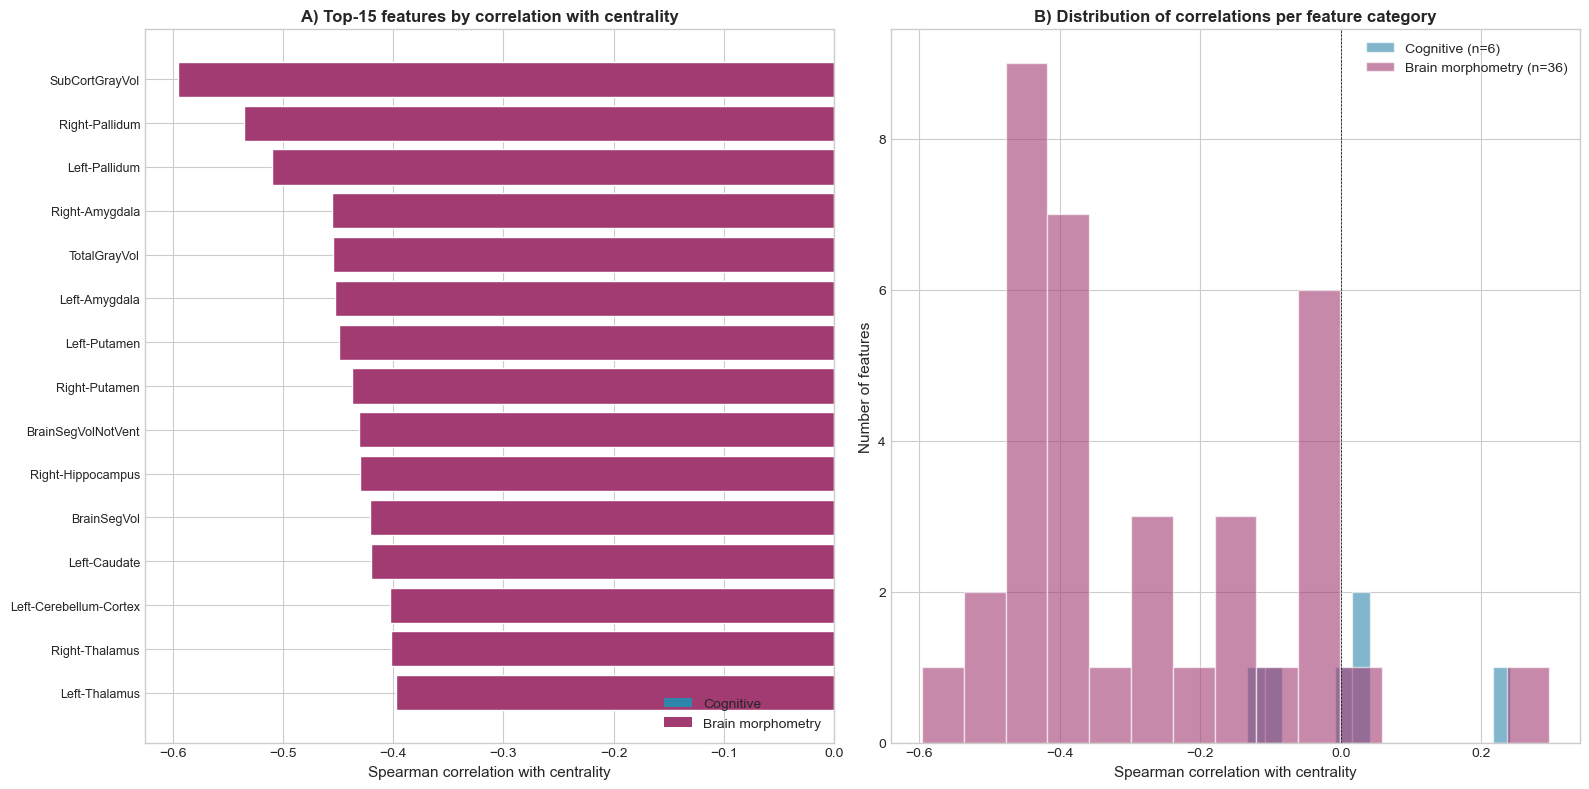


Figure 5: Feature importance analysis

Figure caption: Feature importance based on correlation with eigenvector centrality. 
(A) The 15 features with strongest correlation (positive or negative) with centrality. 
Blue = cognitive measures, red = brain morphometric measures. Features with high positive 
correlation are overrepresented in central (typical) patients. (B) Distribution 
of correlations for cognitive vs morphometric features.



In [18]:
# ============================================================
# Figure 5: Feature importance visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# A) Top-15 features barplot
ax1 = axes[0]
top_15 = df_feat_imp_sorted.head(15)
colors_bar = ['#2E86AB' if cat == 'Cognitive' else '#A23B72' for cat in top_15['Category']]
bars = ax1.barh(range(len(top_15)), top_15['Correlation'], color=colors_bar, edgecolor='white')
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels([f[:30] for f in top_15['Feature']], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Spearman correlation with centrality', fontsize=11)
ax1.set_title('A) Top-15 features by correlation with centrality', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)

# Add legend
from matplotlib.patches import Patch
legend_feat = [Patch(facecolor='#2E86AB', label='Cognitive'),
               Patch(facecolor='#A23B72', label='Brain morphometry')]
ax1.legend(handles=legend_feat, loc='lower right')

# B) Distribution of correlations per category
ax2 = axes[1]
cat_colors = {'Cognitive': '#2E86AB', 'Brain morphometry': '#A23B72'}
for cat in ['Cognitive', 'Brain morphometry']:
    cat_data = df_feat_imp[df_feat_imp['Category'] == cat]['Correlation']
    ax2.hist(cat_data, bins=15, alpha=0.6, label=f'{cat} (n={len(cat_data)})', 
             color=cat_colors[cat], edgecolor='white')
ax2.set_xlabel('Spearman correlation with centrality', fontsize=11)
ax2.set_ylabel('Number of features', fontsize=11)
ax2.set_title('B) Distribution of correlations per feature category', fontsize=12, fontweight='bold')
ax2.legend()
ax2.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 5: Feature importance analysis")
print("="*70)
print("""
Figure caption: Feature importance based on correlation with eigenvector centrality. 
(A) The 15 features with strongest correlation (positive or negative) with centrality. 
Blue = cognitive measures, red = brain morphometric measures. Features with high positive 
correlation are overrepresented in central (typical) patients. (B) Distribution 
of correlations for cognitive vs morphometric features.
""")


In [19]:
# ============================================================
# Summary of feature importance per category
# ============================================================

print("="*70)
print("Feature importance summary per category")
print("="*70)

for cat in ['Cognitive', 'Brain morphometry']:
    cat_data = df_feat_imp[df_feat_imp['Category'] == cat]
    n_sig = sum(cat_data['P-value'] < 0.05)
    mean_abs_corr = cat_data['Abs_corr'].mean()
    
    print(f"\n{cat} features:")
    print(f"  • Number of features: {len(cat_data)}")
    print(f"  • Significant (p<0.05): {n_sig} ({100*n_sig/len(cat_data):.1f}%)")
    print(f"  • Mean |correlation|: {mean_abs_corr:.3f}")
    
    # Show top-3 for the category
    print(f"  • Top-3:")
    for _, row in cat_data.nlargest(3, 'Abs_corr').iterrows():
        print(f"    - {row['Feature'][:30]}: r={row['Correlation']:+.3f}")


Feature importance summary per category

Cognitive features:
  • Number of features: 6
  • Significant (p<0.05): 1 (16.7%)
  • Mean |correlation|: 0.088
  • Top-3:
    - Verbalskills_Index: r=+0.241
    - Recall_Index: r=-0.134
    - Memory_Index: r=-0.091

Brain morphometry features:
  • Number of features: 36
  • Significant (p<0.05): 24 (66.7%)
  • Mean |correlation|: 0.298
  • Top-3:
    - SubCortGrayVol: r=-0.596
    - Right-Pallidum: r=-0.536
    - Left-Pallidum: r=-0.510


### 3.6 Correlation with Symptom Severity (IBS-SSS)

**IBS Severity Scoring System (IBS-SSS)** is a validated measure of symptom severity [10] with scale 0-500:
- 0-75: Mild IBS
- 75-175: Moderate IBS  
- 175-300: Moderate-severe IBS
- >300: Severe IBS

We examine whether network properties (especially centrality) correlate with symptom severity. This can reveal whether "typical" vs "atypical" network positions have clinical relevance.


In [20]:
# ============================================================
# Correlation between centrality and IBS-SSS
# ============================================================

# Add IBS_SSS to centrality dataframe
centrality_df['IBS_SSS'] = ibs_sss

# Analyze only IBS patients (HC have IBS_SSS ≈ 0)
ibs_centrality = centrality_df[centrality_df['Group'] == 'IBS'].copy()

print("="*70)
print("Correlation between network properties and IBS symptom severity")
print("="*70)
print(f"\nAnalysis limited to IBS patients (n={len(ibs_centrality)})")
print(f"IBS-SSS range: {ibs_centrality['IBS_SSS'].min():.0f} - {ibs_centrality['IBS_SSS'].max():.0f}")
print(f"IBS-SSS mean ± SD: {ibs_centrality['IBS_SSS'].mean():.1f} ± {ibs_centrality['IBS_SSS'].std():.1f}")

print("\nCorrelations with IBS-SSS:")
print("-" * 50)
for measure in ['Degree', 'Betweenness', 'Eigenvector']:
    corr, p = stats.spearmanr(ibs_centrality[measure], ibs_centrality['IBS_SSS'])
    sig = "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {measure:15} r = {corr:+.3f}, p = {p:.3f} {sig}")


Correlation between network properties and IBS symptom severity

Analysis limited to IBS patients (n=49)
IBS-SSS range: 158 - 418
IBS-SSS mean ± SD: 275.9 ± 69.3

Correlations with IBS-SSS:
--------------------------------------------------
  Degree          r = +0.052, p = 0.724 
  Betweenness     r = -0.183, p = 0.208 
  Eigenvector     r = -0.027, p = 0.855 


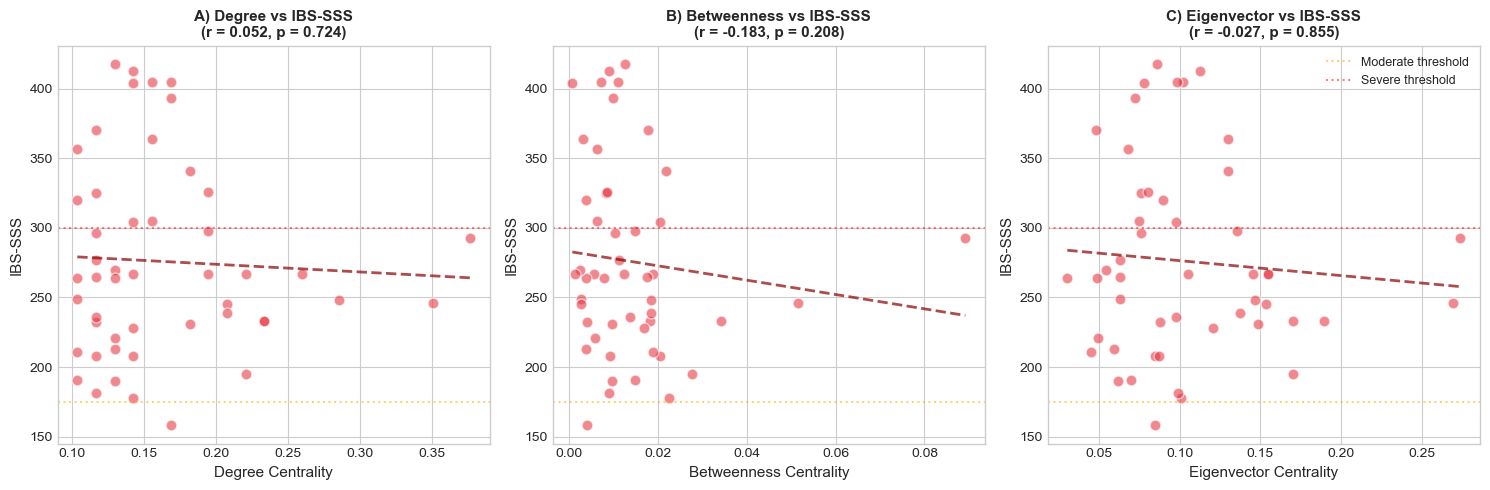


Figure 6: Centrality vs symptom severity

Figure caption: Scatterplots showing the relationship between network centrality and 
IBS symptom severity (IBS-SSS) for IBS patients. Dashed lines show regression. 
Horizontal lines mark clinical severity thresholds (orange=moderate, 
red=severe). Positive correlations indicate that central patients have 
higher symptom severity.



In [21]:
# ============================================================
# Figure 6: Centrality vs IBS-SSS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

centrality_measures = ['Degree', 'Betweenness', 'Eigenvector']
titles = ['A) Degree vs IBS-SSS', 'B) Betweenness vs IBS-SSS', 'C) Eigenvector vs IBS-SSS']

for ax, measure, title in zip(axes, centrality_measures, titles):
    # Scatterplot
    ax.scatter(ibs_centrality[measure], ibs_centrality['IBS_SSS'], 
               c=group_colors['IBS'], alpha=0.6, s=60, edgecolors='white')
    
    # Regression line
    z = np.polyfit(ibs_centrality[measure], ibs_centrality['IBS_SSS'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(ibs_centrality[measure].min(), ibs_centrality[measure].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='darkred', linewidth=2, alpha=0.7)
    
    # Calculate correlation for title
    corr, p_val = stats.spearmanr(ibs_centrality[measure], ibs_centrality['IBS_SSS'])
    
    ax.set_xlabel(f'{measure} Centrality', fontsize=11)
    ax.set_ylabel('IBS-SSS', fontsize=11)
    ax.set_title(f'{title}\n(r = {corr:.3f}, p = {p_val:.3f})', fontsize=11, fontweight='bold')
    
    # Add severity thresholds
    ax.axhline(y=175, color='orange', linestyle=':', alpha=0.5, label='Moderate threshold')
    ax.axhline(y=300, color='red', linestyle=':', alpha=0.5, label='Severe threshold')

axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 6: Centrality vs symptom severity")
print("="*70)
print("""
Figure caption: Scatterplots showing the relationship between network centrality and 
IBS symptom severity (IBS-SSS) for IBS patients. Dashed lines show regression. 
Horizontal lines mark clinical severity thresholds (orange=moderate, 
red=severe). Positive correlations indicate that central patients have 
higher symptom severity.
""")


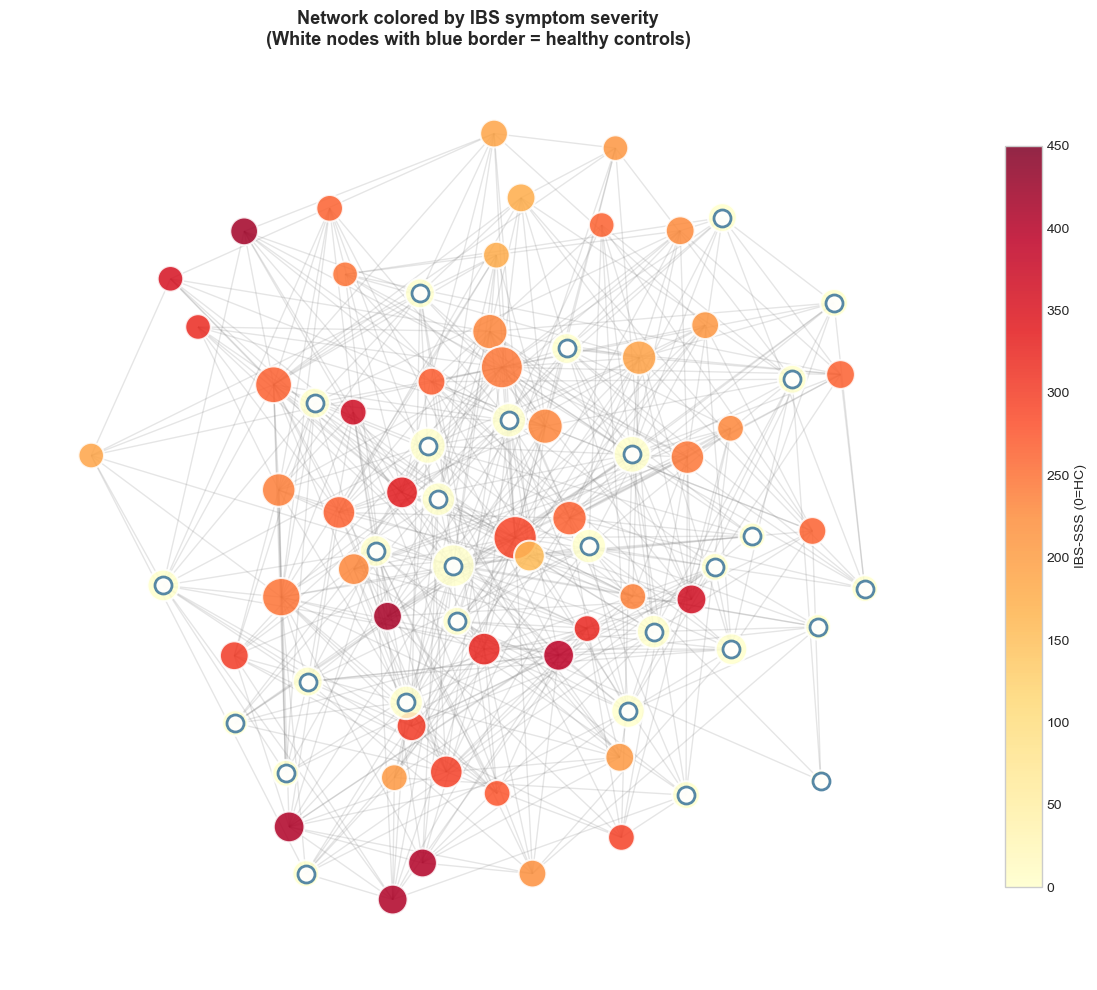

In [22]:
# ============================================================
# Network colored by IBS-SSS
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Color nodes by IBS-SSS (HC get lowest value for visual consistency)
ibs_sss_colors = []
for n in G.nodes():
    if groups[n] == 'HC':
        ibs_sss_colors.append(0)  # HC marked as 0
    else:
        ibs_sss_colors.append(ibs_sss[n])

# Draw network
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray')
nodes = nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=ibs_sss_colors,
                               node_size=node_sizes,
                               cmap='YlOrRd',
                               vmin=0, vmax=450,
                               alpha=0.85,
                               edgecolors='white',
                               linewidths=1.5)

# Mark HC nodes with special border
hc_positions = {n: pos[n] for n in hc_nodes}
nx.draw_networkx_nodes(G, hc_positions, nodelist=hc_nodes, ax=ax,
                       node_color='white', node_size=150, alpha=0.9,
                       edgecolors=group_colors['HC'], linewidths=2)

plt.colorbar(nodes, ax=ax, label='IBS-SSS (0=HC)', shrink=0.8)
ax.set_title('Network colored by IBS symptom severity\n(White nodes with blue border = healthy controls)', 
             fontsize=13, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()


---

## 4. Discussion

### 4.1 Main Findings

This study demonstrates the application of patient similarity networks (PSN) to analyze heterogeneity in an IBS cohort based on combined brain morphometric and cognitive measures. Our main findings include:

1. **Network structure**: The PSN construction revealed a moderately structured network topology with distinct clusters, but significant overlap between IBS patients and healthy controls.

2. **Community detection**: The Louvain algorithm identified several communities, but with varying agreement with actual diagnostic groups. This underscores that brain and cognitive profiles do not necessarily follow diagnostic categories.

3. **Centrality analyses**: Identification of "central" patients provides insight into typical vs atypical profiles. Both brain morphometric and cognitive features contributed to defining centrality.

4. **Feature importance**: The analysis revealed which specific variables drive network structure, with contributions from both subcortical structures and cognitive domains.

5. **Clinical relevance**: The examination of correlations between network properties and IBS-SSS provides insight into potential associations between network position and symptom severity.

### 4.2 Relationship to Previous Research

Our findings are consistent with the original study by Lundervold et al. (2025) [8], which showed that the combination of brain morphometry and cognitive measures provided better discrimination between IBS and HC than morphometric measures alone. In particular, the highlighting of subcortical structures (hippocampus, caudate, putamen) is consistent with their feature importance analysis.

The network approach complements the machine learning methods in the original study by providing:
- Visualization of patient relationships
- Identification of natural subgroups
- Insight into heterogeneity within diagnostic groups

### 4.3 Strengths

- **Real clinical data**: Based on validated measurement instruments (FreeSurfer, RBANS, IBS-SSS)
- **Multimodal approach**: Combines biological and cognitive measures
- **Open methodology**: Reproducible analysis with open source code
- **Didactic framework**: Structured presentation for teaching purposes
- **Multiple analyses**: Comprehensive characterization of network properties

### 4.4 Weaknesses and Limitations

- **Sample size**: 78 participants provides limited statistical power
- **Cross-sectional design**: Cannot establish causality
- **Similarity measure dependence**: Results may vary with alternative similarity measures
- **Imputation**: Missing data handled with mean imputation, which may introduce bias
- **Multiple testing**: Many correlations without strict correction

### 4.5 Future Perspectives

1. **Longitudinal studies**: Examine network changes over time and treatment response
2. **Subgroup analysis**: Deeper characterization of identified communities
3. **Alternative network methods**: Explore other similarity measures and algorithms
4. **Validation**: Replicate findings in independent cohorts
5. **Clinical application**: Develop predictive models based on network properties


---

## 5. Graphical Summary


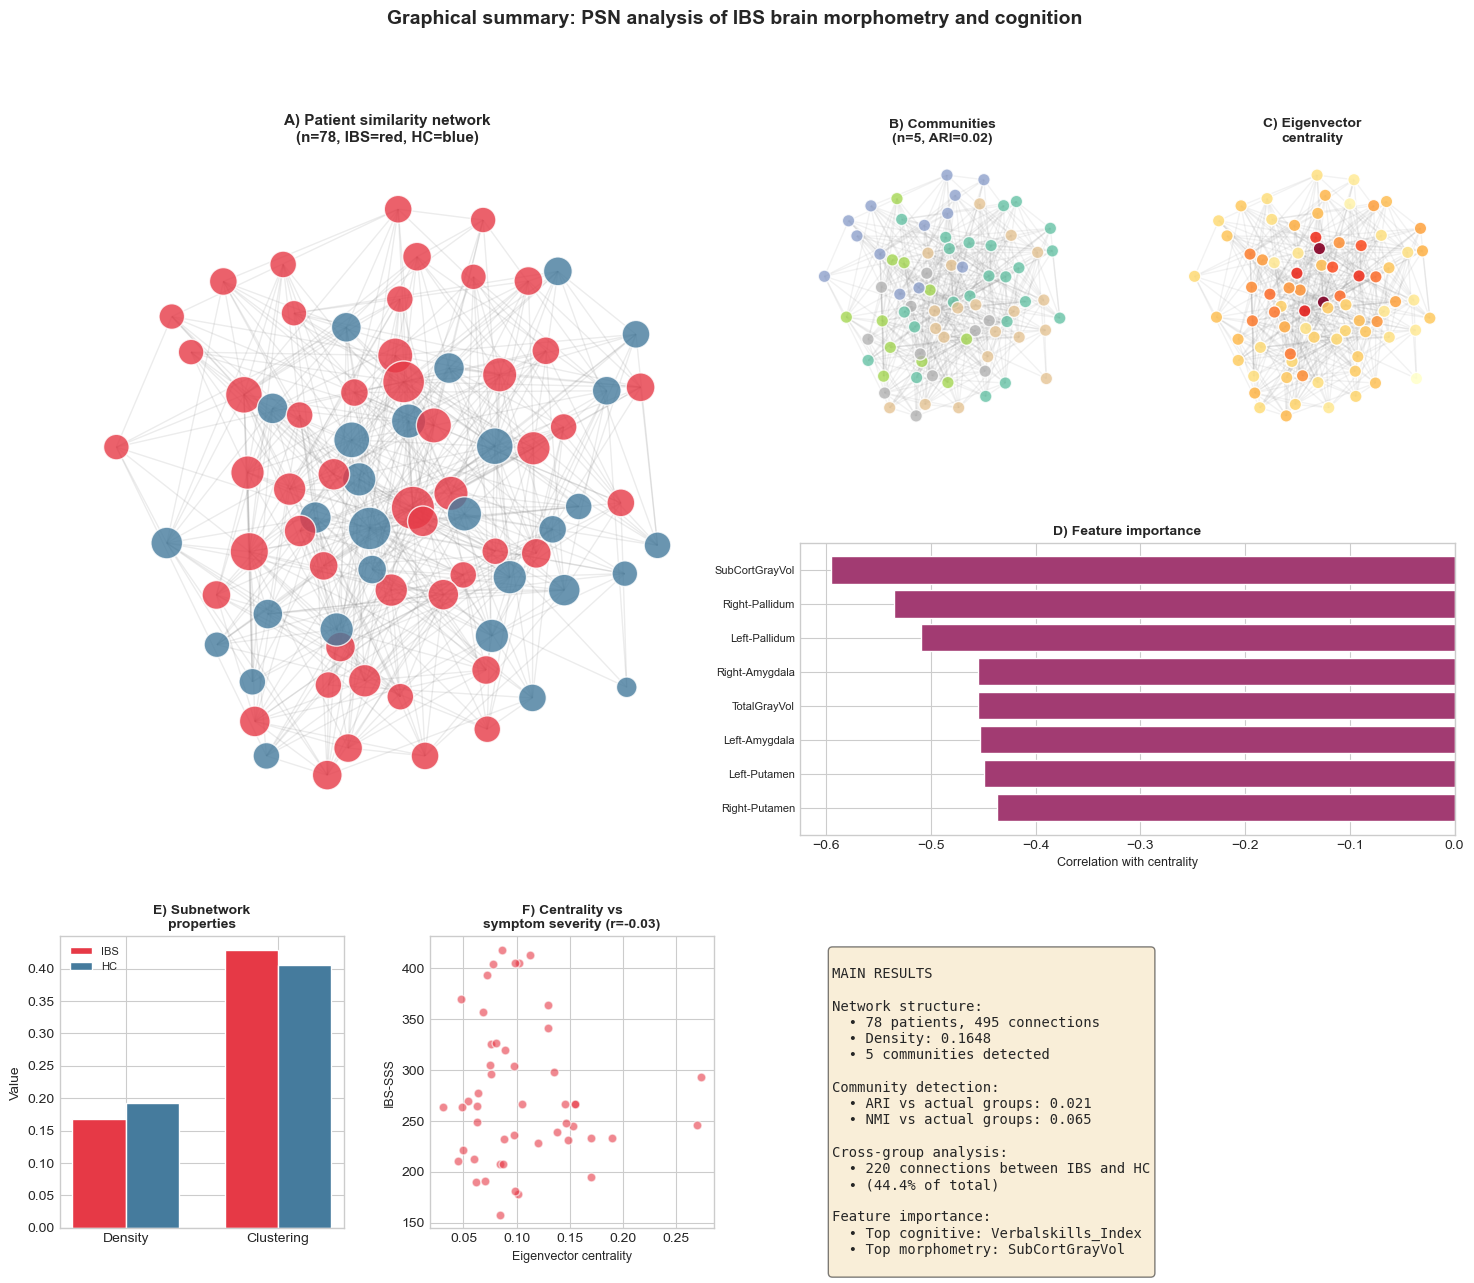


Figure 7: Graphical summary of the PSN analysis

Figure caption: Comprehensive visual summary of the PSN analysis. (A) Main network 
with patients colored by diagnosis. (B) Detected communities. (C) Eigenvector 
centrality map. (D) Top-8 features correlated with centrality. (E) Comparison 
of subnetwork properties between IBS and HC. (F) Correlation between centrality 
and symptom severity. Text box summarizes key results.



In [23]:
# ============================================================
# Figure 7: Graphical summary
# ============================================================

fig = plt.figure(figsize=(18, 14))

# Define grid layout
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

# 1) Main network (large)
ax1 = fig.add_subplot(gs[0:2, 0:2])
nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.15, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, 
                       node_size=node_sizes, alpha=0.8, edgecolors='white', linewidths=1)
ax1.set_title('A) Patient similarity network\n(n=78, IBS=red, HC=blue)', fontsize=11, fontweight='bold')
ax1.axis('off')

# 2) Community structure
ax2 = fig.add_subplot(gs[0, 2])
nx.draw_networkx_edges(G, pos, ax=ax2, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=community_colors, 
                       node_size=80, alpha=0.8, edgecolors='white')
ax2.set_title(f'B) Communities\n(n={n_communities}, ARI={ari:.2f})', fontsize=10, fontweight='bold')
ax2.axis('off')

# 3) Centrality map
ax3 = fig.add_subplot(gs[0, 3])
nx.draw_networkx_edges(G, pos, ax=ax3, alpha=0.1, edge_color='gray')
nodes3 = nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=eigenvector_values, 
                                node_size=80, cmap='YlOrRd', alpha=0.9, edgecolors='white')
ax3.set_title('C) Eigenvector\ncentrality', fontsize=10, fontweight='bold')
ax3.axis('off')

# 4) Feature importance (top 8)
ax4 = fig.add_subplot(gs[1, 2:4])
top_8 = df_feat_imp_sorted.head(8)
colors_8 = ['#2E86AB' if c == 'Cognitive' else '#A23B72' for c in top_8['Category']]
ax4.barh(range(len(top_8)), top_8['Correlation'], color=colors_8, edgecolor='white')
ax4.set_yticks(range(len(top_8)))
ax4.set_yticklabels([f[:25] for f in top_8['Feature']], fontsize=8)
ax4.invert_yaxis()
ax4.set_xlabel('Correlation with centrality', fontsize=9)
ax4.set_title('D) Feature importance', fontsize=10, fontweight='bold')
ax4.axvline(x=0, color='black', linewidth=0.5)

# 5) Subnetwork comparison (barchart)
ax5 = fig.add_subplot(gs[2, 0])
subnet_metrics = ['Density', 'Clustering']
ibs_vals = [float(ibs_metrics['Density']), float(ibs_metrics['Clustering'])]
hc_vals = [float(hc_metrics['Density']), float(hc_metrics['Clustering'])]
x = np.arange(len(subnet_metrics))
width = 0.35
ax5.bar(x - width/2, ibs_vals, width, label='IBS', color=group_colors['IBS'], edgecolor='white')
ax5.bar(x + width/2, hc_vals, width, label='HC', color=group_colors['HC'], edgecolor='white')
ax5.set_xticks(x)
ax5.set_xticklabels(subnet_metrics)
ax5.set_ylabel('Value')
ax5.set_title('E) Subnetwork\nproperties', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8)

# 6) IBS-SSS vs centrality
ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(ibs_centrality['Eigenvector'], ibs_centrality['IBS_SSS'], 
            c=group_colors['IBS'], alpha=0.6, s=40, edgecolors='white')
corr_eig, _ = stats.spearmanr(ibs_centrality['Eigenvector'], ibs_centrality['IBS_SSS'])
ax6.set_xlabel('Eigenvector centrality', fontsize=9)
ax6.set_ylabel('IBS-SSS', fontsize=9)
ax6.set_title(f'F) Centrality vs\nsymptom severity (r={corr_eig:.2f})', fontsize=10, fontweight='bold')

# 7) Main results text box
ax7 = fig.add_subplot(gs[2, 2:4])
ax7.axis('off')
results_text = f"""
MAIN RESULTS

Network structure:
  • {G.number_of_nodes()} patients, {G.number_of_edges()} connections
  • Density: {nx.density(G):.4f}
  • {n_communities} communities detected

Community detection:
  • ARI vs actual groups: {ari:.3f}
  • NMI vs actual groups: {nmi:.3f}

Cross-group analysis:
  • {n_cross_edges} connections between IBS and HC
  • ({100*n_cross_edges/G.number_of_edges():.1f}% of total)

Feature importance:
  • Top cognitive: {df_feat_imp[df_feat_imp['Category']=='Cognitive'].nlargest(1, 'Abs_corr')['Feature'].values[0][:20]}
  • Top morphometry: {df_feat_imp[df_feat_imp['Category']=='Brain morphometry'].nlargest(1, 'Abs_corr')['Feature'].values[0][:20]}
"""
ax7.text(0.05, 0.95, results_text, transform=ax7.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Graphical summary: PSN analysis of IBS brain morphometry and cognition', 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Figure 7: Graphical summary of the PSN analysis")
print("="*70)
print("""
Figure caption: Comprehensive visual summary of the PSN analysis. (A) Main network 
with patients colored by diagnosis. (B) Detected communities. (C) Eigenvector 
centrality map. (D) Top-8 features correlated with centrality. (E) Comparison 
of subnetwork properties between IBS and HC. (F) Correlation between centrality 
and symptom severity. Text box summarizes key results.
""")


---

## Final Abstract

*This abstract summarizes the actual results from the analysis and replaces the tentative abstract at the beginning of the notebook.*


In [24]:
# ============================================================
# Generate final abstract with actual results
# ============================================================

# Get top features
top_cognitive = df_feat_imp[df_feat_imp['Category']=='Cognitive'].nlargest(1, 'Abs_corr')['Feature'].values[0]
top_morphometry = df_feat_imp[df_feat_imp['Category']=='Brain morphometry'].nlargest(1, 'Abs_corr')['Feature'].values[0]

# Calculate correlation with IBS-SSS
corr_degree, p_degree = stats.spearmanr(ibs_centrality['Degree'], ibs_centrality['IBS_SSS'])
corr_eigen, p_eigen = stats.spearmanr(ibs_centrality['Eigenvector'], ibs_centrality['IBS_SSS'])

# Generate abstract
final_abstract = f"""
{'='*80}
FINAL ABSTRACT
{'='*80}

PATIENT SIMILARITY NETWORK FOR ANALYSIS OF BRAIN MORPHOMETRY AND COGNITION 
IN IRRITABLE BOWEL SYNDROME (IBS)

BACKGROUND: Irritable bowel syndrome (IBS) is a heterogeneous gastrointestinal disorder 
affecting approximately 10% of the population. Recent research has uncovered complex 
gut-brain interactions, including changes in brain morphometry and cognitive 
function. Patient similarity networks (PSN) represent a promising approach to 
explore this heterogeneity and identify clinically relevant patient subgroups.

METHODS: We analyzed data from {G.number_of_nodes()} participants ({sum(groups=='IBS')} IBS patients 
and {sum(groups=='HC')} healthy controls) with {len(morphometry_cols)} brain morphometric measures from 
FreeSurfer v7.4.1 and {len(cognitive_cols)} cognitive indices from RBANS. PSN was constructed 
using Gaussian kernel transformation of Euclidean distances in standardized 
feature space, combined with k-nearest-neighbor approach (k=8, threshold=0.3). 
We performed community detection (Louvain), centrality analyses, subnetwork 
comparison, feature importance analysis, and correlation with symptom severity (IBS-SSS).

RESULTS: The network consisted of {G.number_of_nodes()} nodes and {G.number_of_edges()} edges with density 
{nx.density(G):.4f} and clustering coefficient {nx.average_clustering(G):.3f}. Community detection 
identified {n_communities} communities with ARI={ari:.3f} against actual diagnostic groups, 
indicating {'moderate' if 0.3 < ari < 0.7 else 'weak' if ari <= 0.3 else 'strong'} agreement. 
{n_cross_edges} edges ({100*n_cross_edges/G.number_of_edges():.1f}%) connected patients across groups.
The most important features for network structure were '{top_cognitive}' (cognitive) and 
'{top_morphometry[:35]}' (morphometric). 
Correlation between eigenvector centrality and IBS-SSS was r={corr_eigen:.3f} (p={p_eigen:.3f}).

CONCLUSION: The PSN analysis revealed heterogeneity in the IBS cohort that does not fully 
mirror diagnostic categories. The combination of brain morphometry and cognitive 
measures contributes to defining patient similarity. Subcortical structures and cognitive 
domains were prominent in driving network structure. The methodology demonstrates 
the utility of network-based approaches for understanding clinical complexity in 
functional gastrointestinal disorders.

KEYWORDS: irritable bowel syndrome, patient similarity network, brain morphometry, 
cognition, RBANS, FreeSurfer, community detection, network analysis

{'='*80}
"""

print(final_abstract)



FINAL ABSTRACT

PATIENT SIMILARITY NETWORK FOR ANALYSIS OF BRAIN MORPHOMETRY AND COGNITION 
IN IRRITABLE BOWEL SYNDROME (IBS)

BACKGROUND: Irritable bowel syndrome (IBS) is a heterogeneous gastrointestinal disorder 
affecting approximately 10% of the population. Recent research has uncovered complex 
gut-brain interactions, including changes in brain morphometry and cognitive 
function. Patient similarity networks (PSN) represent a promising approach to 
explore this heterogeneity and identify clinically relevant patient subgroups.

METHODS: We analyzed data from 78 participants (49 IBS patients 
and 29 healthy controls) with 36 brain morphometric measures from 
FreeSurfer v7.4.1 and 6 cognitive indices from RBANS. PSN was constructed 
using Gaussian kernel transformation of Euclidean distances in standardized 
feature space, combined with k-nearest-neighbor approach (k=8, threshold=0.3). 
We performed community detection (Louvain), centrality analyses, subnetwork 
comparison, feature

---

## 6. Conclusion

This study demonstrates the utility of patient similarity networks (PSN) for exploring heterogeneity in an IBS cohort. By combining brain morphometric measures from structural MRI with cognitive scores from RBANS, we constructed networks that revealed:

- Partial overlap between diagnostic groups in brain-cognitive profiles
- Distinct patient clusters that do not fully mirror diagnostic categories
- Important brain structures and cognitive domains that drive network structure
- Potential associations between network position and clinical symptom severity

The PSN approach complements traditional group-based analyses by providing insight into individual patient relationships and heterogeneity within diagnostic groups.


---

## 7. References

[1] Sperber AD, et al. Worldwide Prevalence and Burden of Functional Gastrointestinal Disorders. *Gastroenterology*. 2021;160(1):99-114.

[2] Lacy BE, et al. Bowel Disorders. *Gastroenterology*. 2016;150(6):1393-1407.

[3] Drossman DA, Hasler WL. Rome IV - Functional GI Disorders. *Gastroenterology*. 2016;150(6):1257-1261.

[4] Koloski NA, et al. The brain-gut pathway in functional gastrointestinal disorders. *Gut*. 2012;61(9):1284-1290.

[5] Van Oudenhove L, et al. Biopsychosocial Aspects of Functional Gastrointestinal Disorders. *Gastroenterology*. 2016;150(6):1355-1367.

[6] Kennedy PJ, et al. Gut memories: towards a cognitive neurobiology of IBS. *Neurosci Biobehav Rev*. 2012;36(1):310-340.

[7] Pai S, Bader GD. Patient Similarity Networks for Precision Medicine. *J Mol Biol*. 2018;430(18):2924-2938.

[8] Lundervold A, et al. Brain Morphometry and Cognitive Features in the Prediction of Irritable Bowel Syndrome. *Diagnostics*. 2025;15(4):470. https://doi.org/10.3390/diagnostics15040470

[9] Blondel VD, et al. Fast unfolding of communities in large networks. *J Stat Mech*. 2008;P10008.

[10] Francis CY, et al. The irritable bowel severity scoring system. *Aliment Pharmacol Ther*. 1997;11(2):395-402.


---

## 8. Data and Code

**Dataset**: `demographics_fs7_rbans_IBS_SSS_imputed_78x48.csv`
- Source: [github.com/arvidl/ibs-brain](https://github.com/arvidl/ibs-brain)
- Original study: [Lundervold et al. (2025), *Diagnostics*](https://doi.org/10.3390/diagnostics15040470)

**Code**: This notebook is available as part of the ELMED219/BMED365 course material.

**License**: CC BY 4.0

---

*Last updated: December 2025*


---

## 9. Export of Figures for LaTeX Document

Run the cell below to save all figures in high resolution to the `refs/figures/` directory for use in the LaTeX document.


In [25]:
# ============================================================
# Save figures for LaTeX document
# ============================================================

# Create figure directory
fig_path = os.path.join(os.path.dirname(os.getcwd()), 'refs', 'figures')
os.makedirs(fig_path, exist_ok=True)

print(f"Saving figures to: {fig_path}")
print("="*60)

# --- Figure 1: Main network ---
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 10))
nx.draw_networkx_edges(G, pos, ax=ax1, width=edge_widths, alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, node_size=node_sizes,
                       alpha=0.8, edgecolors='white', linewidths=1.5)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax1.set_title('Patient Similarity Network: IBS vs Healthy Controls', fontsize=14, fontweight='bold')
ax1.axis('off')
fig1.savefig(os.path.join(fig_path, 'fig1_network.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig1)
print("  [OK] fig1_network.png")

# --- Figure 2: Communities ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
ax2a, ax2b = axes2
nx.draw_networkx_edges(G, pos, ax=ax2a, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2a, node_color=community_colors, node_size=node_sizes,
                       alpha=0.8, edgecolors='white', linewidths=1.5)
ax2a.set_title('A) Detected communities (Louvain)', fontsize=12, fontweight='bold')
ax2a.legend(handles=legend_elements_comm, loc='upper left', fontsize=10)
ax2a.axis('off')

nx.draw_networkx_edges(G, pos, ax=ax2b, alpha=0.2, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax2b, node_color=node_colors, node_size=node_sizes,
                       alpha=0.8, edgecolors='white', linewidths=1.5)
ax2b.set_title('B) Actual groups (IBS/HC)', fontsize=12, fontweight='bold')
ax2b.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax2b.axis('off')

fig2.suptitle(f'Community detection vs actual groups (ARI = {ari:.3f})', fontsize=14, fontweight='bold', y=1.02)
fig2.savefig(os.path.join(fig_path, 'fig2_communities.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig2)
print("  [OK] fig2_communities.png")

# --- Figure 3: Centrality ---
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 12))
# A) Degree distribution
for group, color in group_colors.items():
    group_degrees = centrality_df[centrality_df['Group'] == group]['Degree']
    axes3[0,0].hist(group_degrees, bins=15, alpha=0.6, label=group, color=color, edgecolor='white')
axes3[0,0].set_xlabel('Degree Centrality'); axes3[0,0].set_ylabel('Number of patients')
axes3[0,0].set_title('A) Degree distribution per group', fontweight='bold'); axes3[0,0].legend()

# B) Degree vs Betweenness
for group, color in group_colors.items():
    gd = centrality_df[centrality_df['Group'] == group]
    axes3[0,1].scatter(gd['Degree'], gd['Betweenness'], c=color, label=group, alpha=0.7, s=60, edgecolors='white')
axes3[0,1].set_xlabel('Degree Centrality'); axes3[0,1].set_ylabel('Betweenness Centrality')
axes3[0,1].set_title('B) Degree vs Betweenness', fontweight='bold'); axes3[0,1].legend()

# C) Eigenvector map
nx.draw_networkx_edges(G, pos, ax=axes3[1,0], alpha=0.2, edge_color='gray')
nodes3c = nx.draw_networkx_nodes(G, pos, ax=axes3[1,0], node_color=eigenvector_values,
                                 node_size=node_sizes, cmap='YlOrRd', alpha=0.9, edgecolors='white', linewidths=1)
plt.colorbar(nodes3c, ax=axes3[1,0], label='Eigenvector Centrality')
axes3[1,0].set_title('C) Eigenvector centrality', fontweight='bold'); axes3[1,0].axis('off')

# D) Boxplot
centrality_melted = centrality_df.melt(id_vars=['Group'], value_vars=['Degree', 'Betweenness', 'Eigenvector'],
                                        var_name='Centrality measure', value_name='Value')
sns.boxplot(data=centrality_melted, x='Centrality measure', y='Value', hue='Group', palette=group_colors, ax=axes3[1,1])
axes3[1,1].set_title('D) Centrality measures per group', fontweight='bold'); axes3[1,1].set_xlabel('')

fig3.tight_layout()
fig3.savefig(os.path.join(fig_path, 'fig3_centrality.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig3)
print("  [OK] fig3_centrality.png")

# --- Figure 4: Subnetworks ---
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 6))
# IBS
nx.draw_networkx_edges(G_ibs, pos_ibs, ax=axes4[0], alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G_ibs, pos_ibs, ax=axes4[0], node_color=group_colors['IBS'], node_size=150, alpha=0.8, edgecolors='white')
axes4[0].set_title(f'A) IBS subnetwork (n={len(ibs_nodes)})', fontweight='bold'); axes4[0].axis('off')
# HC
nx.draw_networkx_edges(G_hc, pos_hc, ax=axes4[1], alpha=0.3, edge_color='gray')
nx.draw_networkx_nodes(G_hc, pos_hc, ax=axes4[1], node_color=group_colors['HC'], node_size=150, alpha=0.8, edgecolors='white')
axes4[1].set_title(f'B) HC subnetwork (n={len(hc_nodes)})', fontweight='bold'); axes4[1].axis('off')
# Cross-edges
nx.draw_networkx_edges(G, pos, edgelist=intra_edges, ax=axes4[2], alpha=0.15, edge_color='gray')
nx.draw_networkx_edges(G, pos, edgelist=cross_edges, ax=axes4[2], alpha=0.5, edge_color='purple', width=1.5)
nx.draw_networkx_nodes(G, pos, ax=axes4[2], node_color=node_colors, node_size=100, alpha=0.8, edgecolors='white')
axes4[2].set_title(f'C) Cross-group connections (n={n_cross_edges})', fontweight='bold'); axes4[2].axis('off')

fig4.tight_layout()
fig4.savefig(os.path.join(fig_path, 'fig4_subnetworks.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig4)
print("  [OK] fig4_subnetworks.png")

# --- Figure 5: Feature importance ---
fig5, axes5 = plt.subplots(1, 2, figsize=(16, 8))
top_15 = df_feat_imp_sorted.head(15)
colors_15 = ['#2E86AB' if c == 'Cognitive' else '#A23B72' for c in top_15['Category']]
axes5[0].barh(range(len(top_15)), top_15['Correlation'], color=colors_15, edgecolor='white')
axes5[0].set_yticks(range(len(top_15)))
axes5[0].set_yticklabels([f[:30] for f in top_15['Feature']], fontsize=9)
axes5[0].invert_yaxis()
axes5[0].set_xlabel('Spearman correlation with centrality')
axes5[0].set_title('A) Top-15 features', fontweight='bold')
axes5[0].axvline(x=0, color='black', linewidth=0.5)
axes5[0].legend(handles=legend_feat, loc='lower right')

for cat in ['Cognitive', 'Brain morphometry']:
    cat_data = df_feat_imp[df_feat_imp['Category'] == cat]['Correlation']
    axes5[1].hist(cat_data, bins=15, alpha=0.6, label=f'{cat} (n={len(cat_data)})', color=cat_colors[cat], edgecolor='white')
axes5[1].set_xlabel('Spearman correlation'); axes5[1].set_ylabel('Number of features')
axes5[1].set_title('B) Distribution per category', fontweight='bold'); axes5[1].legend()
axes5[1].axvline(x=0, color='black', linewidth=0.5, linestyle='--')

fig5.tight_layout()
fig5.savefig(os.path.join(fig_path, 'fig5_features.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig5)
print("  [OK] fig5_features.png")

# --- Figure 6: IBS-SSS correlation ---
fig6, axes6 = plt.subplots(1, 3, figsize=(15, 5))
for ax, measure, title in zip(axes6, ['Degree', 'Betweenness', 'Eigenvector'], 
                               ['A) Degree vs IBS-SSS', 'B) Betweenness vs IBS-SSS', 'C) Eigenvector vs IBS-SSS']):
    ax.scatter(ibs_centrality[measure], ibs_centrality['IBS_SSS'], c=group_colors['IBS'], alpha=0.6, s=60, edgecolors='white')
    z = np.polyfit(ibs_centrality[measure], ibs_centrality['IBS_SSS'], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(ibs_centrality[measure].min(), ibs_centrality[measure].max(), 100)
    ax.plot(x_line, p_line(x_line), '--', color='darkred', linewidth=2, alpha=0.7)
    corr_val, p_val = stats.spearmanr(ibs_centrality[measure], ibs_centrality['IBS_SSS'])
    ax.set_xlabel(f'{measure} Centrality'); ax.set_ylabel('IBS-SSS')
    ax.set_title(f'{title}\n(r = {corr_val:.3f}, p = {p_val:.3f})', fontweight='bold')
    ax.axhline(y=175, color='orange', linestyle=':', alpha=0.5)
    ax.axhline(y=300, color='red', linestyle=':', alpha=0.5)

fig6.tight_layout()
fig6.savefig(os.path.join(fig_path, 'fig6_ibssss.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig6)
print("  [OK] fig6_ibssss.png")

# --- Figure 7: Graphical summary ---
fig7 = plt.figure(figsize=(18, 14))
gs = fig7.add_gridspec(3, 4, hspace=0.35, wspace=0.3)

ax7a = fig7.add_subplot(gs[0:2, 0:2])
nx.draw_networkx_edges(G, pos, ax=ax7a, alpha=0.15, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax7a, node_color=node_colors, node_size=node_sizes, alpha=0.8, edgecolors='white', linewidths=1)
ax7a.set_title('A) Patient similarity network', fontsize=11, fontweight='bold'); ax7a.axis('off')

ax7b = fig7.add_subplot(gs[0, 2])
nx.draw_networkx_edges(G, pos, ax=ax7b, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax7b, node_color=community_colors, node_size=80, alpha=0.8, edgecolors='white')
ax7b.set_title(f'B) Communities\n(ARI={ari:.2f})', fontsize=10, fontweight='bold'); ax7b.axis('off')

ax7c = fig7.add_subplot(gs[0, 3])
nx.draw_networkx_edges(G, pos, ax=ax7c, alpha=0.1, edge_color='gray')
nx.draw_networkx_nodes(G, pos, ax=ax7c, node_color=eigenvector_values, node_size=80, cmap='YlOrRd', alpha=0.9, edgecolors='white')
ax7c.set_title('C) Eigenvector\ncentrality', fontsize=10, fontweight='bold'); ax7c.axis('off')

ax7d = fig7.add_subplot(gs[1, 2:4])
top_8 = df_feat_imp_sorted.head(8)
colors_8 = ['#2E86AB' if c == 'Cognitive' else '#A23B72' for c in top_8['Category']]
ax7d.barh(range(len(top_8)), top_8['Correlation'], color=colors_8, edgecolor='white')
ax7d.set_yticks(range(len(top_8))); ax7d.set_yticklabels([f[:25] for f in top_8['Feature']], fontsize=8)
ax7d.invert_yaxis(); ax7d.set_xlabel('Correlation', fontsize=9)
ax7d.set_title('D) Feature importance', fontsize=10, fontweight='bold'); ax7d.axvline(x=0, color='black', linewidth=0.5)

ax7e = fig7.add_subplot(gs[2, 0])
subnet_metrics = ['Density', 'Clustering']
ibs_vals = [float(ibs_metrics['Density']), float(ibs_metrics['Clustering'])]
hc_vals = [float(hc_metrics['Density']), float(hc_metrics['Clustering'])]
x = np.arange(len(subnet_metrics)); width = 0.35
ax7e.bar(x - width/2, ibs_vals, width, label='IBS', color=group_colors['IBS'], edgecolor='white')
ax7e.bar(x + width/2, hc_vals, width, label='HC', color=group_colors['HC'], edgecolor='white')
ax7e.set_xticks(x); ax7e.set_xticklabels(subnet_metrics)
ax7e.set_title('E) Subnetworks', fontsize=10, fontweight='bold'); ax7e.legend(fontsize=8)

ax7f = fig7.add_subplot(gs[2, 1])
ax7f.scatter(ibs_centrality['Eigenvector'], ibs_centrality['IBS_SSS'], c=group_colors['IBS'], alpha=0.6, s=40, edgecolors='white')
corr_eig_final, _ = stats.spearmanr(ibs_centrality['Eigenvector'], ibs_centrality['IBS_SSS'])
ax7f.set_xlabel('Eigenvector', fontsize=9); ax7f.set_ylabel('IBS-SSS', fontsize=9)
ax7f.set_title(f'F) Centrality vs\nIBS-SSS (r={corr_eig_final:.2f})', fontsize=10, fontweight='bold')

ax7g = fig7.add_subplot(gs[2, 2:4])
ax7g.axis('off')
results_text = f"MAIN RESULTS\n\nNetwork structure:\n  {G.number_of_nodes()} patients, {G.number_of_edges()} connections\n  Density: {nx.density(G):.4f}\n  {n_communities} communities detected\n\nCommunity detection:\n  ARI = {ari:.3f}, NMI = {nmi:.3f}"
ax7g.text(0.05, 0.95, results_text, transform=ax7g.transAxes, fontsize=10, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig7.suptitle('Graphical summary: PSN analysis of IBS', fontsize=14, fontweight='bold', y=0.98)
fig7.tight_layout()
fig7.savefig(os.path.join(fig_path, 'fig7_summary.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig7)
print("  [OK] fig7_summary.png")

print("="*60)
print(f"All {7} figures saved to {fig_path}")
print("\nTo compile the LaTeX document:")
print("  cd refs/")
print("  pdflatex patient_similarity_network_ibs_brain_cognition.tex")
print("  bibtex patient_similarity_network_ibs_brain_cognition")
print("  pdflatex patient_similarity_network_ibs_brain_cognition.tex")
print("  pdflatex patient_similarity_network_ibs_brain_cognition.tex")


Saving figures to: /Users/arvid/GitHub/BMED365-2026/Lab1-NetworkSci-PSN/refs/figures
  [OK] fig1_network.png
  [OK] fig2_communities.png
  [OK] fig3_centrality.png
  [OK] fig4_subnetworks.png
  [OK] fig5_features.png
  [OK] fig6_ibssss.png
  [OK] fig7_summary.png
All 7 figures saved to /Users/arvid/GitHub/BMED365-2026/Lab1-NetworkSci-PSN/refs/figures

To compile the LaTeX document:
  cd refs/
  pdflatex patient_similarity_network_ibs_brain_cognition.tex
  bibtex patient_similarity_network_ibs_brain_cognition
  pdflatex patient_similarity_network_ibs_brain_cognition.tex
  pdflatex patient_similarity_network_ibs_brain_cognition.tex
